# Imports & Setup

In [21]:
import os
from pathlib import Path
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

from math import sqrt

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from scipy.stats import wilcoxon, friedmanchisquare

from xgboost import XGBRegressor
import optuna
from pythermalcomfort.models import utci

In [22]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Style
plt.style.use("seaborn-v0_8-whitegrid")
matplotlib.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "figure.dpi": 150,
})

# Paths
PROJECT_DIR = Path(".")
DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "thermal_comfort_outputs"
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
SPLIT_DIR = OUTPUT_DIR / "splits"

for d in [OUTPUT_DIR, FIG_DIR, TABLE_DIR, SPLIT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Unified dataset configuration
DATASET_NAME = "ERA5 hourly reanalysis"
DATASET_SOURCE = "ECMWF / Copernicus ERA5"
START_YEAR = 2011
END_YEAR = 2020
TRAIN_START_YEAR = 2011
TRAIN_END_YEAR = 2018
VAL_YEAR = 2019
TEST_YEAR = 2020

print(DATASET_NAME, DATASET_SOURCE)
print(f"Years: {START_YEAR}-{END_YEAR}")

ERA5 hourly reanalysis ECMWF / Copernicus ERA5
Years: 2011-2020


## Data Loading

In [8]:
#storing the data
DATA_DIR = "data/"
years = range(2011, 2021)
all_years = []

#Loop Through Each Year
for y in years:
    print("Processing", y)

    #Loading Climate Variables
    d2m = xr.open_dataset(f"{DATA_DIR}/d2m_{y}_hourly.nc")
    ssrd = xr.open_dataset(f"{DATA_DIR}/ssrd_{y}_hourly.nc")
    uv = xr.open_dataset(f"{DATA_DIR}/uv_{y}_hourly.nc")

   # Loading Temperature seperate because it is in Paired Files
    if y <= 2012:
        t2m = xr.open_dataset(f"{DATA_DIR}/t2m_2011_2012_hourly.nc")
    elif y <= 2014:
        t2m = xr.open_dataset(f"{DATA_DIR}/t2m_2013_2014_hourly.nc")
    elif y <= 2016:
        t2m = xr.open_dataset(f"{DATA_DIR}/t2m_2015_2016_hourly.nc")
    elif y <= 2018:
        t2m = xr.open_dataset(f"{DATA_DIR}/t2m_2017_2018_hourly.nc")
    else:
        t2m = xr.open_dataset(f"{DATA_DIR}/t2m_2019_2020_hourly.nc")

    # Select year
    t2m_y = t2m.sel(valid_time=str(y))

    #Mergeing All Variables Into One Dataset
    ds = xr.merge([t2m_y, d2m, ssrd, uv])
    
    #Convert xarray Dataset → Pandas DataFrame
    df = ds.to_dataframe().reset_index()

    # Store this year's data
    all_years.append(df)

    # Combine all years
final = pd.concat(all_years, ignore_index=True)

# Save
final.to_csv("era5_2011_2020_RAWdata.csv", index=False)
print("Shape:", final.shape)    

Processing 2011
Processing 2012
Processing 2013
Processing 2014
Processing 2015
Processing 2016
Processing 2017
Processing 2018
Processing 2019
Processing 2020
Shape: (28318056, 10)


## Data Cleaning and Meteorological Feature Engineering

In [9]:
# Rename timestamp column and set to datetime
df = df.rename(columns={"valid_time": "timestamp"})
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

# Bridge short gaps by linear interpolation (limit gaps <= 3 hours)
df = df.set_index("timestamp").interpolate(method="time", limit=3).reset_index()

# Drop any rows with remaining NaNs (if any)
df = df.dropna().reset_index(drop=True)

C:\Users\User\AppData\Local\Temp\ipykernel_9820\4066232727.py:7: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.set_index("timestamp").interpolate(method="time", limit=3).reset_index()


In [11]:
df

,timestamp,latitude,longitude,number,expver,t2m,d2m,ssrd,u10,v10
0,2020-01-01 00:00:00,9.00,2.00,0,0001,295.524414,278.470947,0.0,-1.073364,-3.251907
1,2020-01-01 00:00:00,6.25,4.75,0,0001,296.661133,294.955322,0.0,0.537964,-1.312454
2,2020-01-01 00:00:00,6.25,4.50,0,0001,297.598633,295.119385,0.0,1.112183,-0.726517
3,2020-01-01 00:00:00,6.25,4.25,0,0001,300.625977,296.447510,0.0,2.135620,-0.394485
4,2020-01-01 00:00:00,6.25,4.00,0,0001,301.510742,296.269775,0.0,2.899292,0.548874
...,...,...,...,...,...,...,...,...,...,...
2837227,2020-12-31 23:00:00,7.75,4.00,0,0001,299.187134,297.039551,0.0,0.791916,1.563873
2837228,2020-12-31 23:00:00,7.75,3.75,0,0001,298.987915,296.809082,0.0,0.420822,1.645905
2837229,2020-12-31 23:00:00,7.75,3.50,0,0001,298.601196,296.539551,0.0,-0.026443,1.526764
2837230,2020-12-31 23:00:00,7.50,3.25,0,0001,299.564087,297.424316,0.0,0.554611,1.830475


In [107]:
final

,valid_time,latitude,longitude,number,expver,t2m,d2m,ssrd,u10,v10
0,2011-01-01 00:00:00,9.0,2.00,0,0001,295.178223,277.011963,0.0,-1.358612,-3.729965
1,2011-01-01 00:00:00,9.0,2.25,0,0001,295.160645,277.496338,0.0,-1.444550,-3.658676
2,2011-01-01 00:00:00,9.0,2.50,0,0001,295.129395,276.996338,0.0,-1.545135,-3.533676
3,2011-01-01 00:00:00,9.0,2.75,0,0001,295.029785,277.308838,0.0,-1.538300,-3.483871
4,2011-01-01 00:00:00,9.0,3.00,0,0001,294.754395,277.982666,0.0,-1.707245,-3.457504
...,...,...,...,...,...,...,...,...,...,...
28318051,2020-12-31 23:00:00,5.0,5.50,0,0001,300.261353,298.428223,0.0,3.714767,2.501373
28318052,2020-12-31 23:00:00,5.0,5.75,0,0001,299.614868,298.453613,0.0,2.044846,1.916412
28318053,2020-12-31 23:00:00,5.0,6.00,0,0001,299.550415,298.357910,0.0,1.667892,1.923248
28318054,2020-12-31 23:00:00,5.0,6.25,0,0001,299.692993,298.340332,0.0,1.725510,1.974030


In [111]:
final.to_csv("era5_Merge_raw_dataset.csv", index=False)

In [2]:
df = pd.read_csv("era5_Merge_raw_dataset.csv")

In [3]:
df

,valid_time,latitude,longitude,number,expver,t2m,d2m,ssrd,u10,v10
0,2011-01-01 00:00:00,9.0,2.00,0,1,295.17822,277.01196,0.0,-1.358612,-3.729965
1,2011-01-01 00:00:00,9.0,2.25,0,1,295.16064,277.49634,0.0,-1.444550,-3.658676
2,2011-01-01 00:00:00,9.0,2.50,0,1,295.12940,276.99634,0.0,-1.545135,-3.533676
3,2011-01-01 00:00:00,9.0,2.75,0,1,295.02980,277.30884,0.0,-1.538300,-3.483871
4,2011-01-01 00:00:00,9.0,3.00,0,1,294.75440,277.98267,0.0,-1.707245,-3.457504
...,...,...,...,...,...,...,...,...,...,...
28318051,2020-12-31 23:00:00,5.0,5.50,0,1,300.26135,298.42822,0.0,3.714767,2.501373
28318052,2020-12-31 23:00:00,5.0,5.75,0,1,299.61487,298.45360,0.0,2.044846,1.916412
28318053,2020-12-31 23:00:00,5.0,6.00,0,1,299.55040,298.35790,0.0,1.667893,1.923248
28318054,2020-12-31 23:00:00,5.0,6.25,0,1,299.69300,298.34033,0.0,1.725510,1.974030


In [4]:
# Rename timestamp column and set to datetime
df = df.rename(columns={"valid_time": "timestamp"})
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

# Bridge short gaps by linear interpolation (limit gaps <= 3 hours)
df = df.set_index("timestamp").interpolate(method="time", limit=3).reset_index()

# Drop any rows with remaining NaNs
df = df.dropna().reset_index(drop=True)

In [5]:
df

,timestamp,latitude,longitude,number,expver,t2m,d2m,ssrd,u10,v10
0,2011-01-01 00:00:00,9.00,2.00,0,1,295.17822,277.01196,0.0,-1.358612,-3.729965
1,2011-01-01 00:00:00,6.25,4.75,0,1,294.79540,292.30690,0.0,-0.170135,-1.401840
2,2011-01-01 00:00:00,6.25,4.50,0,1,296.74854,292.28345,0.0,-0.296112,-1.270981
3,2011-01-01 00:00:00,6.25,4.25,0,1,300.35986,292.65260,0.0,-0.390839,-1.516098
4,2011-01-01 00:00:00,6.25,4.00,0,1,301.40674,292.63306,0.0,-0.230682,-1.226059
...,...,...,...,...,...,...,...,...,...,...
24337430,2020-12-31 23:00:00,7.75,4.00,0,1,299.18713,297.03955,0.0,0.791916,1.563873
24337431,2020-12-31 23:00:00,7.75,3.75,0,1,298.98790,296.80908,0.0,0.420822,1.645905
24337432,2020-12-31 23:00:00,7.75,3.50,0,1,298.60120,296.53955,0.0,-0.026443,1.526764
24337433,2020-12-31 23:00:00,7.50,3.25,0,1,299.56410,297.42432,0.0,0.554611,1.830475


In [6]:
print(df.isnull().sum())

timestamp    0
latitude     0
longitude    0
number       0
expver       0
t2m          0
d2m          0
ssrd         0
u10          0
v10          0
dtype: int64


In [7]:
# Convert temperature to Celsius
df["ta"] = df["t2m"] - 273.15    # Air temperature (°C)

# Calculate dew point (°C)
Td = df["d2m"] - 273.15

# Compute relative humidity (%) using Magnus formula
T = df["ta"]
df["rh"] = 100 * (
    np.exp((17.625 * Td) / (243.04 + Td)) /
    np.exp((17.625 * T)  / (243.04 + T))
)

# Compute wind speed (m/s) from u10, v10
df["ws"] = np.sqrt(df["u10"]**2 + df["v10"]**2)

# Convert surface solar radiation from J/m² to W/m² (hourly sum to average)
df["sr"] = df["ssrd"] / 3600.0

# Keep only relevant columns
df = df[["timestamp", "latitude", "longitude", "ta", "rh", "ws", "sr"]]

## Map Southwest State Capitals to Nearest ERA5 Grid

In [8]:
# Select state capitals in SW Nigeria and map to nearest grid
states = {
    "Lagos": (6.60, 3.35),   # Ikeja
    "Ogun":  (7.15, 3.35),   # Abeokuta
    "Oyo":   (7.38, 3.92),   # Ibadan
    "Osun":  (7.77, 4.56),   # Osogbo
    "Ondo":  (7.25, 5.20),   # Akure
    "Ekiti": (7.62, 5.22),   # Ado-Ekiti
}
# Unique grid points in data
grid = df[["latitude", "longitude"]].drop_duplicates().reset_index(drop=True)
def nearest_point(lat, lon):
    dist = (grid.latitude - lat)**2 + (grid.longitude - lon)**2
    idx = dist.idxmin()
    return float(grid.loc[idx, "latitude"]), float(grid.loc[idx, "longitude"])

state_records = []
for state, (lat, lon) in states.items():
    glat, glon = nearest_point(lat, lon)
    state_df = df[(np.isclose(df.latitude, glat)) & (np.isclose(df.longitude, glon))].copy()
    state_df["state"] = state
    state_records.append(state_df)
capitals_df = pd.concat(state_records, ignore_index=True)

In [9]:
# Pivot to wide format: each state’s variables become separate columns
wide = capitals_df.pivot_table(
    index="timestamp",
    columns="state",
    values=["ta","rh","ws","sr"],
    aggfunc="mean"
)
wide.columns = [f"{var}_{state}" for var, state in wide.columns]
wide = wide.reset_index().sort_values("timestamp")
wide.head()

,timestamp,rh_Ekiti,rh_Lagos,rh_Ogun,rh_Ondo,rh_Osun,rh_Oyo,sr_Ekiti,sr_Lagos,sr_Ogun,...,ta_Ogun,ta_Ondo,ta_Osun,ta_Oyo,ws_Ekiti,ws_Lagos,ws_Ogun,ws_Ondo,ws_Osun,ws_Oyo
0,2011-01-01 00:00:00,42.434970,69.339358,71.252682,54.043706,38.990827,58.555304,0.0,0.0,0.0,...,21.60440,19.95205,22.04775,21.08486,3.603634,1.114619,1.956445,3.383393,3.810494,3.204726
1,2011-01-01 01:00:00,41.242659,75.077924,73.091526,49.356117,37.486534,56.313946,0.0,0.0,0.0,...,21.43300,20.21620,22.15957,20.57560,3.573461,2.314787,1.796623,3.511808,3.835900,3.411031
2,2011-01-01 02:00:00,41.515831,78.058054,74.642361,50.580577,37.740212,51.636660,0.0,0.0,0.0,...,20.64150,19.35635,21.66494,20.04385,3.631577,2.542531,1.858606,3.473376,3.872248,3.492871
3,2011-01-01 03:00:00,37.972071,76.310596,69.727706,41.792023,34.218000,42.207692,0.0,0.0,0.0,...,18.17788,17.72670,19.30680,17.81850,3.855922,2.572764,2.113754,3.567491,4.107549,3.729557
4,2011-01-01 04:00:00,38.487609,75.951497,68.542576,41.274952,34.400217,35.885450,0.0,0.0,0.0,...,17.77260,17.39956,19.17495,18.28433,3.910598,2.628775,2.199580,3.583661,4.140956,4.011516


In [10]:
print(wide.isnull().sum())

timestamp        0
rh_Ekiti      8243
rh_Lagos     25763
rh_Ogun      15928
rh_Ondo       8243
rh_Osun       4515
rh_Oyo       21138
sr_Ekiti      8243
sr_Lagos     25763
sr_Ogun      15928
sr_Ondo       8243
sr_Osun       4515
sr_Oyo       21138
ta_Ekiti      8243
ta_Lagos     25763
ta_Ogun      15928
ta_Ondo       8243
ta_Osun       4515
ta_Oyo       21138
ws_Ekiti      8243
ws_Lagos     25763
ws_Ogun      15928
ws_Ondo       8243
ws_Osun       4515
ws_Oyo       21138
dtype: int64


In [11]:
wide_clean = wide.dropna()

In [12]:
print(wide_clean.isnull().sum())

timestamp    0
rh_Ekiti     0
rh_Lagos     0
rh_Ogun      0
rh_Ondo      0
rh_Osun      0
rh_Oyo       0
sr_Ekiti     0
sr_Lagos     0
sr_Ogun      0
sr_Ondo      0
sr_Osun      0
sr_Oyo       0
ta_Ekiti     0
ta_Lagos     0
ta_Ogun      0
ta_Ondo      0
ta_Osun      0
ta_Oyo       0
ws_Ekiti     0
ws_Lagos     0
ws_Ogun      0
ws_Ondo      0
ws_Osun      0
ws_Oyo       0
dtype: int64


In [13]:
wide = wide_clean.copy()

## Time Feature Engineering

In [14]:
# Encode cyclical time features (hour of day, day of year)
wide["hour"] = wide["timestamp"].dt.hour
wide["dayofyear"] = wide["timestamp"].dt.dayofyear
# Trigonometric encoding for cyclical patterns:contentReference[oaicite:1]{index=1}:
wide["hour_sin"] = np.sin(2*np.pi * wide["hour"] / 24.0)
wide["hour_cos"] = np.cos(2*np.pi * wide["hour"] / 24.0)
wide["day_sin"]  = np.sin(2*np.pi * (wide["dayofyear"]-1) / 365.0)
wide["day_cos"]  = np.cos(2*np.pi * (wide["dayofyear"]-1) / 365.0)

## UTCI Target Variable

We compute UTCI for each state using the `pythermalcomfort` implementation.

**Important note:** UTCI requires:
- dry bulb temperature (`tdb`)
- mean radiant temperature (`tr`)
- wind speed (`v`)
- relative humidity (`rh`)

Because direct MRT is not present in the ERA5 extraction, we use a simple approximation:
**tr ≈ ta + 0.02 × sr**

You should mention this approximation clearly in the paper as a methodological limitation.

In [15]:
from pythermalcomfort.models import utci

# Compute UTCI for each state; we use a simple approximation for mean radiant temperature (MRT)
states_list = list(states.keys())
for state in states_list:
    t_db = wide[f"ta_{state}"].values
    rh   = wide[f"rh_{state}"].values
    v    = wide[f"ws_{state}"].values
    # Approximate MRT as Ta + 0.02*SR (a common ISO approximation)
    t_mrt = t_db + 0.02 * wide[f"sr_{state}"].values
    # Compute UTCI (returns an array in °C)
    utci_vals = utci(tdb=t_db, tr=t_mrt, v=v, rh=rh)
    wide[f"utci_{state}"] = np.array(utci_vals.utci).astype(float)

# Example: print UTCI distribution for Lagos
print(wide["utci_Lagos"].describe())

count    61027.000000
mean        28.200143
std          3.228228
min         14.500000
25%         26.100000
50%         27.900000
75%         30.000000
max         38.400000
Name: utci_Lagos, dtype: float64


In [17]:
wide.describe()

,timestamp,rh_Ekiti,rh_Lagos,rh_Ogun,rh_Ondo,rh_Osun,rh_Oyo,sr_Ekiti,sr_Lagos,sr_Ogun,...,hour_sin,hour_cos,day_sin,day_cos,utci_Lagos,utci_Ogun,utci_Oyo,utci_Osun,utci_Ondo,utci_Ekiti
count,61368,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,...,6.136800e+04,6.136800e+04,6.136800e+04,61368.000000,61027.000000,59787.000000,59728.000000,59630.000000,60094.000000,60034.000000
mean,2015-12-06 22:16:30.457567488,79.071556,83.886457,79.030542,81.252375,78.352080,80.136687,196.536923,196.241192,193.407570,...,-1.843859e-17,-5.547497e-17,-2.223051e-17,0.000782,28.200143,29.534367,28.557208,27.929071,27.551771,27.190221
min,2011-01-01 00:00:00,11.923468,19.884965,8.606067,12.452305,5.308735,9.638226,-0.000528,-0.000528,-0.000528,...,-1.000000e+00,-1.000000e+00,-9.999907e-01,-0.999963,14.500000,13.500000,11.000000,9.800000,10.400000,9.300000
25%,2013-10-02 05:45:00,68.226427,80.320271,70.651076,71.840703,67.750497,71.577890,0.000000,0.000000,0.000000,...,-7.071068e-01,-7.071068e-01,-7.055836e-01,-0.708627,26.100000,26.800000,25.800000,25.000000,24.900000,24.300000
50%,2015-07-03 11:30:00,86.876501,86.236689,84.281583,88.619691,86.433778,87.017149,6.702222,7.040000,6.471111,...,6.123234e-17,-6.123234e-17,0.000000e+00,0.004304,27.900000,28.700000,27.700000,26.900000,26.600000,26.100000
75%,2019-04-02 17:15:00,95.009913,89.822039,92.142696,95.318096,94.807605,94.708860,375.844444,387.986667,377.515556,...,7.071068e-01,7.071068e-01,7.055836e-01,0.702527,30.000000,31.700000,30.800000,30.400000,29.700000,29.700000
max,2020-12-31 23:00:00,100.015628,99.188781,100.002208,100.016810,100.016237,100.011711,1035.537778,982.222222,991.697778,...,1.000000e+00,1.000000e+00,9.999907e-01,1.000000,38.400000,43.400000,42.700000,42.400000,42.300000,41.900000
std,NaN,20.193519,9.011128,16.983539,18.598757,21.028902,19.051473,272.688551,262.630424,264.153516,...,7.071125e-01,7.071125e-01,7.068359e-01,0.707389,3.228228,3.964188,4.146992,4.469508,4.213754,4.507868


In [16]:
DF = wide.copy()

In [17]:
DF

,timestamp,rh_Ekiti,rh_Lagos,rh_Ogun,rh_Ondo,rh_Osun,rh_Oyo,sr_Ekiti,sr_Lagos,sr_Ogun,...,hour_sin,hour_cos,day_sin,day_cos,utci_Lagos,utci_Ogun,utci_Oyo,utci_Osun,utci_Ondo,utci_Ekiti
0,2011-01-01 00:00:00,42.434970,69.339358,71.252682,54.043706,38.990827,58.555304,0.0,0.0,0.0,...,0.000000,1.000000,0.000000e+00,1.0,26.8,21.0,17.7,17.0,15.7,16.2
1,2011-01-01 01:00:00,41.242659,75.077924,73.091526,49.356117,37.486534,56.313946,0.0,0.0,0.0,...,0.258819,0.965926,0.000000e+00,1.0,24.2,21.1,16.6,17.0,15.6,16.2
2,2011-01-01 02:00:00,41.515831,78.058054,74.642361,50.580577,37.740212,51.636660,0.0,0.0,0.0,...,0.500000,0.866025,0.000000e+00,1.0,22.9,20.2,15.5,16.3,14.7,15.6
3,2011-01-01 03:00:00,37.972071,76.310596,69.727706,41.792023,34.218000,42.207692,0.0,0.0,0.0,...,0.707107,0.707107,0.000000e+00,1.0,20.9,16.7,12.0,12.9,12.1,12.4
4,2011-01-01 04:00:00,38.487609,75.951497,68.542576,41.274952,34.400217,35.885450,0.0,0.0,0.0,...,0.866025,0.500000,0.000000e+00,1.0,20.3,16.0,11.8,12.6,11.7,11.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87126,2020-12-31 19:00:00,51.029875,82.284763,63.796043,59.460032,39.632017,53.987061,0.0,0.0,0.0,...,-0.965926,0.258819,6.432491e-16,1.0,28.2,29.7,29.2,29.0,27.3,28.2
87127,2020-12-31 20:00:00,72.099848,85.926341,77.105324,76.101753,58.493294,72.926495,0.0,0.0,0.0,...,-0.866025,0.500000,6.432491e-16,1.0,27.9,28.4,27.3,26.6,25.9,26.1
87128,2020-12-31 21:00:00,75.400886,87.054258,82.229323,81.607035,75.397755,81.677406,0.0,0.0,0.0,...,-0.707107,0.707107,6.432491e-16,1.0,27.9,28.7,27.8,26.6,26.9,26.4
87129,2020-12-31 22:00:00,81.914958,89.507877,88.832043,86.947565,83.015257,92.022992,0.0,0.0,0.0,...,-0.500000,0.866025,6.432491e-16,1.0,27.4,28.3,27.1,24.1,25.6,25.0


In [18]:
print(df.isnull().sum())

timestamp    0
latitude     0
longitude    0
ta           0
rh           0
ws           0
sr           0
dtype: int64


In [19]:
print(DF.isnull().sum())

timestamp        0
rh_Ekiti         0
rh_Lagos         0
rh_Ogun          0
rh_Ondo          0
rh_Osun          0
rh_Oyo           0
sr_Ekiti         0
sr_Lagos         0
sr_Ogun          0
sr_Ondo          0
sr_Osun          0
sr_Oyo           0
ta_Ekiti         0
ta_Lagos         0
ta_Ogun          0
ta_Ondo          0
ta_Osun          0
ta_Oyo           0
ws_Ekiti         0
ws_Lagos         0
ws_Ogun          0
ws_Ondo          0
ws_Osun          0
ws_Oyo           0
hour             0
dayofyear        0
hour_sin         0
hour_cos         0
day_sin          0
day_cos          0
utci_Lagos     341
utci_Ogun     1581
utci_Oyo      1640
utci_Osun     1738
utci_Ondo     1274
utci_Ekiti    1334
dtype: int64


In [20]:
DF = DF.dropna()

In [21]:
print(DF.isnull().sum())

timestamp     0
rh_Ekiti      0
rh_Lagos      0
rh_Ogun       0
rh_Ondo       0
rh_Osun       0
rh_Oyo        0
sr_Ekiti      0
sr_Lagos      0
sr_Ogun       0
sr_Ondo       0
sr_Osun       0
sr_Oyo        0
ta_Ekiti      0
ta_Lagos      0
ta_Ogun       0
ta_Ondo       0
ta_Osun       0
ta_Oyo        0
ws_Ekiti      0
ws_Lagos      0
ws_Ogun       0
ws_Ondo       0
ws_Osun       0
ws_Oyo        0
hour          0
dayofyear     0
hour_sin      0
hour_cos      0
day_sin       0
day_cos       0
utci_Lagos    0
utci_Ogun     0
utci_Oyo      0
utci_Osun     0
utci_Ondo     0
utci_Ekiti    0
dtype: int64


## Exploratory Data Analysis

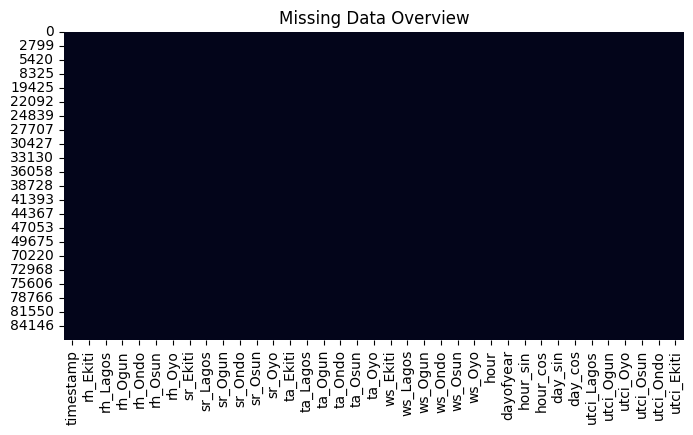

In [29]:
# 5.2 Missing Data
plt.figure(figsize=(8,4))
sns.heatmap(DF.isnull(), cbar=False)
plt.title("Missing Data Overview")
plt.show()

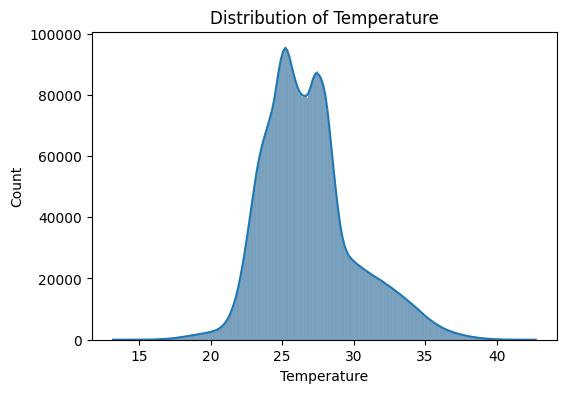

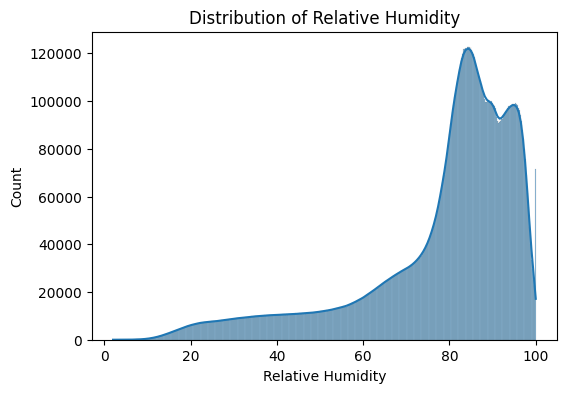

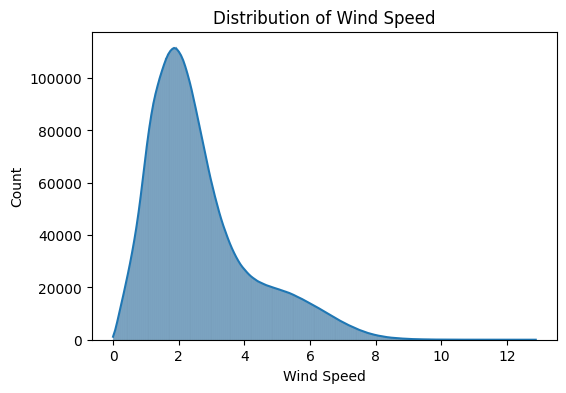

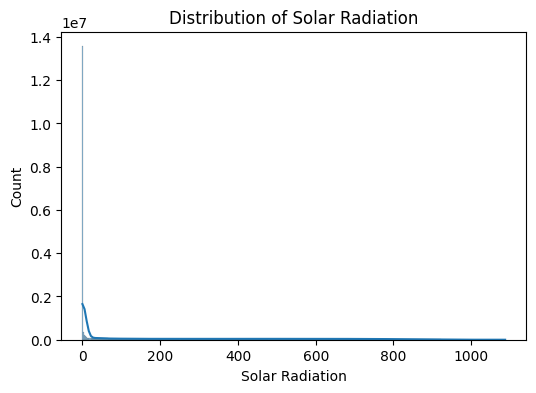

In [4]:
variables = ["ta", "rh", "ws", "sr"]

# Create a mapping dictionary
var_names = {
    "ta": "Temperature",
    "rh": "Relative Humidity",
    "ws": "Wind Speed",
    "sr": "Solar Radiation"
}

for var in variables:
    plt.figure(figsize=(6,4))
    sns.histplot(df[var], kde=True)
    plt.title(f"Distribution of {var_names[var]}")
    plt.xlabel(var_names[var])  # optional but recommended
    plt.show()

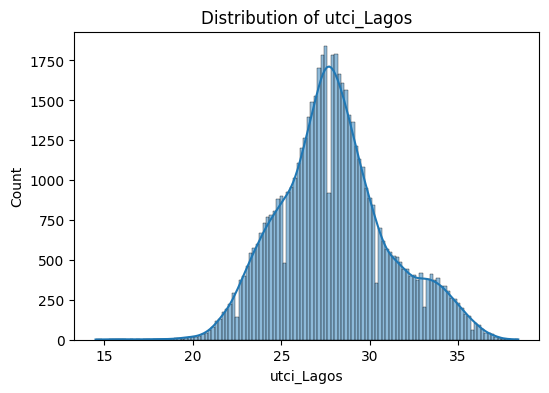

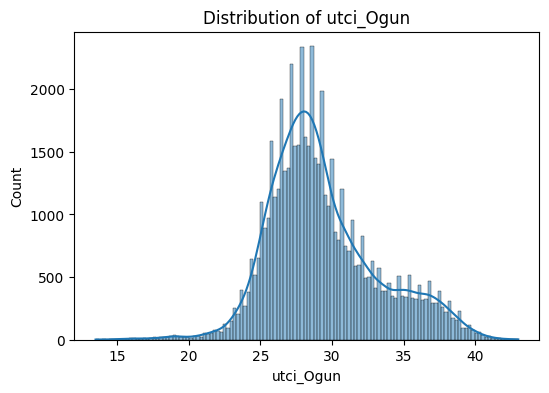

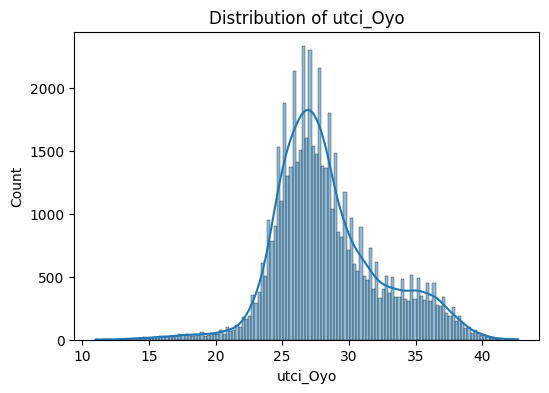

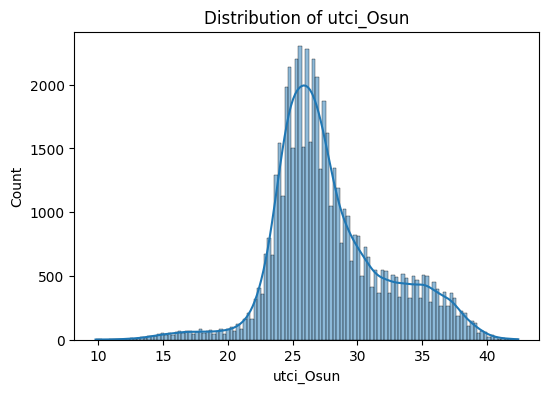

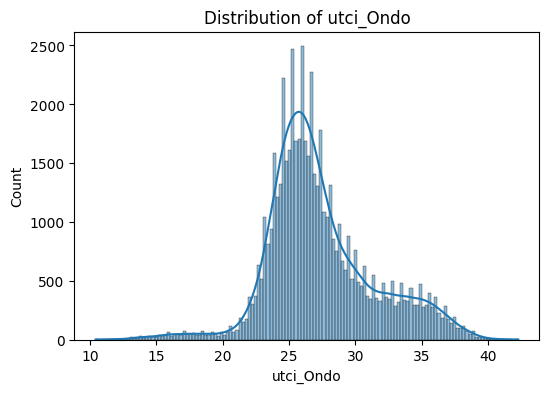

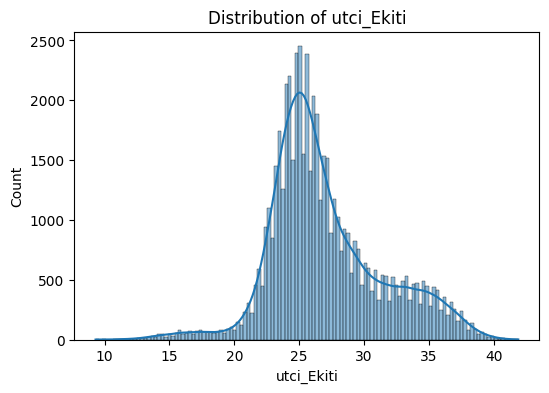

In [31]:
#Variable Distributions
variables = ["utci_Lagos", "utci_Ogun", "utci_Oyo", "utci_Osun", "utci_Ondo", "utci_Ekiti"]

for var in variables:
    plt.figure(figsize=(6,4))
    sns.histplot(DF[var], kde=True)
    plt.title(f"Distribution of {var}")
    plt.show()

In [133]:
variables = ["ta","rh","ws","sr"]

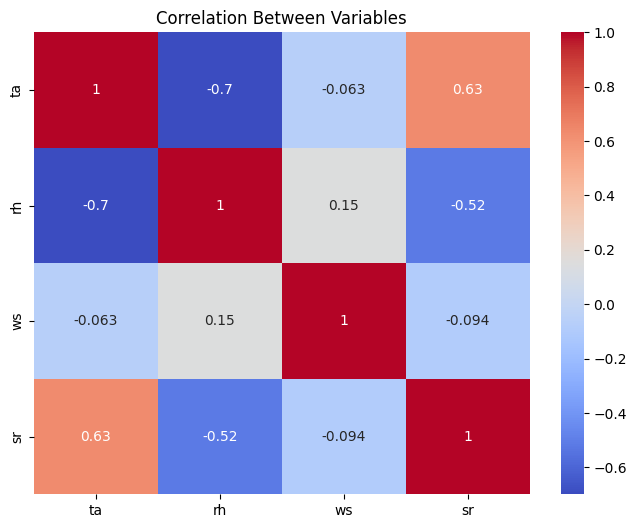

In [134]:
variables = ["ta", "rh", "ws", "sr"]

var_names = {
    "ta": "Temperature",
    "rh": "Relative Humidity",
    "ws": "Wind Speed",
    "sr": "Solar Radiation"
}

# Rename columns temporarily for plotting
corr_matrix = df[variables].rename(columns=var_names).corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Between Meteorological Variables")
plt.show()

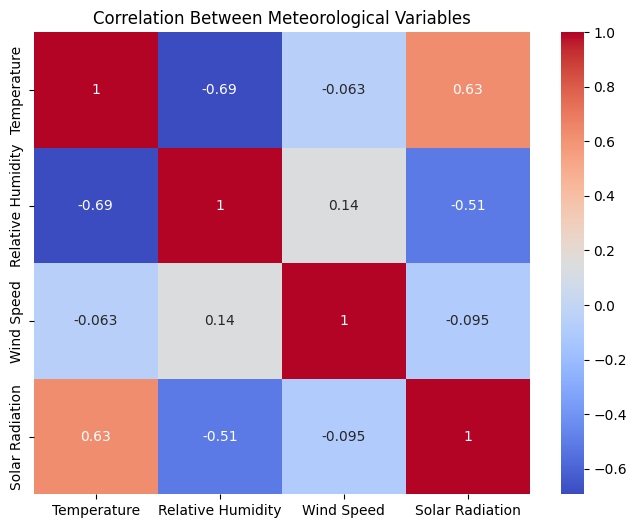

In [5]:
variables = ["ta", "rh", "ws", "sr"]

var_names = {
    "ta": "Temperature",
    "rh": "Relative Humidity",
    "ws": "Wind Speed",
    "sr": "Solar Radiation"
}

# Rename columns temporarily for plotting
corr_matrix = df[variables].rename(columns=var_names).corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Between Meteorological Variables")
plt.show()

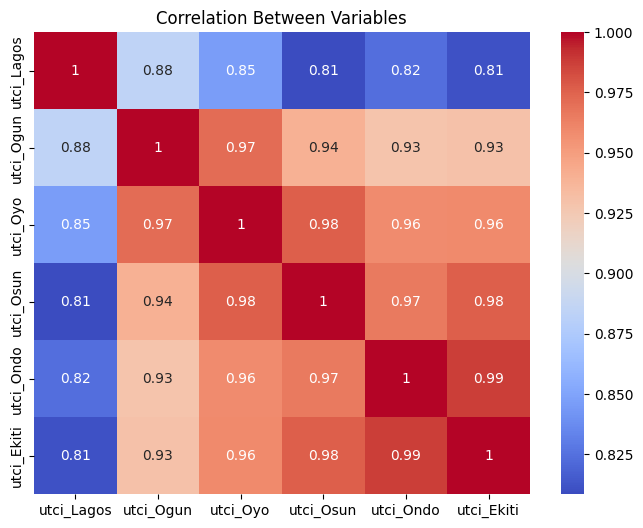

In [32]:
# Correlation Heatmap
variables = ["utci_Lagos", "utci_Ogun", "utci_Oyo", "utci_Osun", "utci_Ondo", "utci_Ekiti"]
plt.figure(figsize=(8,6))
sns.heatmap(DF[variables].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Variables")
plt.show()

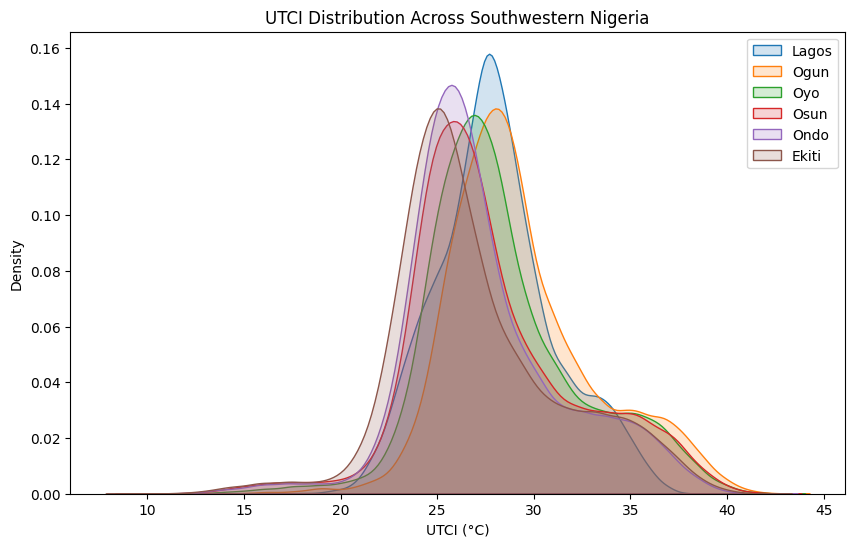

In [34]:
# Variable distributions per state
plt.figure(figsize=(10,6))

for var in variables:
    state = var.split("_")[1]
    sns.kdeplot(DF[var], label=state, fill=True, alpha=0.2)

plt.title("UTCI Distribution Across Southwestern Nigeria")
plt.xlabel("UTCI (°C)")
plt.legend()
plt.show()

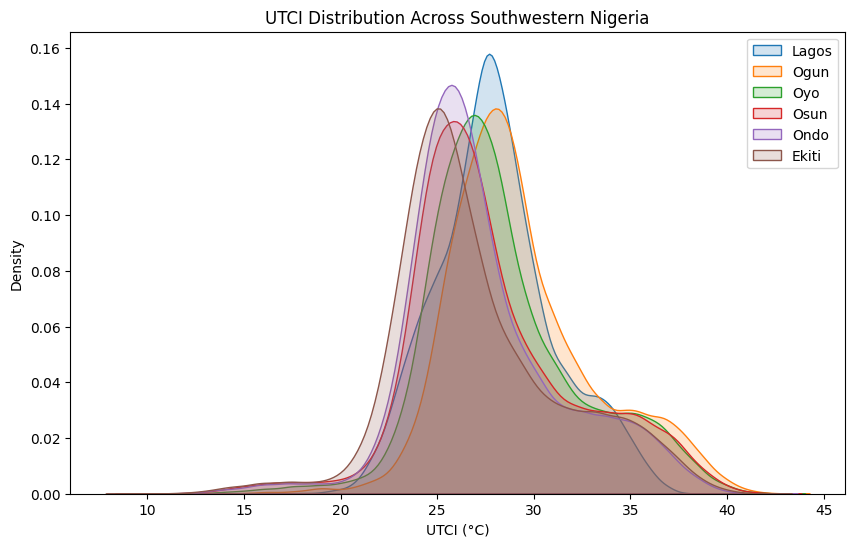

In [35]:
# Variable distributions per state
plt.figure(figsize=(10,6))

for var in variables:
    state = var.split("_")[1]
    sns.kdeplot(DF[var], label=state, fill=True, alpha=0.2)

plt.title("UTCI Distribution Across Southwestern Nigeria")
plt.xlabel("UTCI (°C)")
plt.legend()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_17124\3445177059.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["hour"] = DF["timestamp"].dt.hour


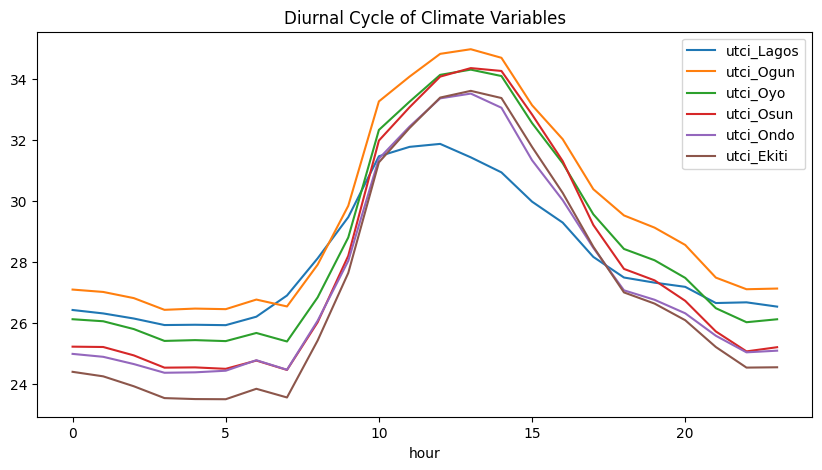

In [36]:
# 6 Diurnal Pattern
df["hour"] = DF["timestamp"].dt.hour

hourly = DF.groupby("hour")[variables].mean()

hourly.plot(figsize=(10,5))
plt.title("Diurnal Cycle of Climate Variables")
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_16576\1177841114.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["hour"] = DF["timestamp"].dt.hour


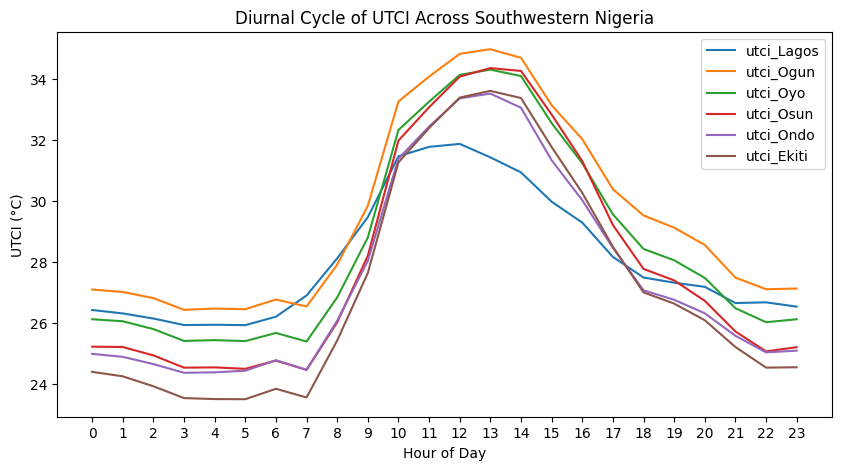

In [30]:
# Extract hour
df["hour"] = DF["timestamp"].dt.hour

# Group
hourly = DF.groupby("hour")[variables].mean()

# Plot
ax = hourly.plot(figsize=(10,5))

# Force all hours (0–23) to show
ax.set_xticks(range(24))

plt.title("Diurnal Cycle of UTCI Across Southwestern Nigeria")
plt.xlabel("Hour of Day")
plt.ylabel("UTCI (°C)")
plt.show()

In [26]:
variables = ["utci_Lagos", "utci_Ogun", "utci_Oyo", "utci_Osun", "utci_Ondo", "utci_Ekiti"]

In [54]:
DF.columns

Index(['timestamp', 'rh_Ekiti', 'rh_Lagos', 'rh_Ogun', 'rh_Ondo', 'rh_Osun',
       'rh_Oyo', 'sr_Ekiti', 'sr_Lagos', 'sr_Ogun', 'sr_Ondo', 'sr_Osun',
       'sr_Oyo', 'ta_Ekiti', 'ta_Lagos', 'ta_Ogun', 'ta_Ondo', 'ta_Osun',
       'ta_Oyo', 'ws_Ekiti', 'ws_Lagos', 'ws_Ogun', 'ws_Ondo', 'ws_Osun',
       'ws_Oyo', 'hour', 'dayofyear', 'hour_sin', 'hour_cos', 'day_sin',
       'day_cos', 'utci_Lagos', 'utci_Ogun', 'utci_Oyo', 'utci_Osun',
       'utci_Ondo', 'utci_Ekiti'],
      dtype='object')

In [24]:
DF

,timestamp,rh_Ekiti,rh_Lagos,rh_Ogun,rh_Ondo,rh_Osun,rh_Oyo,sr_Ekiti,sr_Lagos,sr_Ogun,...,hour_sin,hour_cos,day_sin,day_cos,utci_Lagos,utci_Ogun,utci_Oyo,utci_Osun,utci_Ondo,utci_Ekiti
0,2011-01-01 00:00:00,42.434970,69.339358,71.252682,54.043706,38.990827,58.555304,0.0,0.0,0.0,...,0.000000,1.000000,0.000000e+00,1.0,26.8,21.0,17.7,17.0,15.7,16.2
1,2011-01-01 01:00:00,41.242659,75.077924,73.091526,49.356117,37.486534,56.313946,0.0,0.0,0.0,...,0.258819,0.965926,0.000000e+00,1.0,24.2,21.1,16.6,17.0,15.6,16.2
2,2011-01-01 02:00:00,41.515831,78.058054,74.642361,50.580577,37.740212,51.636660,0.0,0.0,0.0,...,0.500000,0.866025,0.000000e+00,1.0,22.9,20.2,15.5,16.3,14.7,15.6
3,2011-01-01 03:00:00,37.972071,76.310596,69.727706,41.792023,34.218000,42.207692,0.0,0.0,0.0,...,0.707107,0.707107,0.000000e+00,1.0,20.9,16.7,12.0,12.9,12.1,12.4
4,2011-01-01 04:00:00,38.487609,75.951497,68.542576,41.274952,34.400217,35.885450,0.0,0.0,0.0,...,0.866025,0.500000,0.000000e+00,1.0,20.3,16.0,11.8,12.6,11.7,11.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87126,2020-12-31 19:00:00,51.029875,82.284763,63.796043,59.460032,39.632017,53.987061,0.0,0.0,0.0,...,-0.965926,0.258819,6.432491e-16,1.0,28.2,29.7,29.2,29.0,27.3,28.2
87127,2020-12-31 20:00:00,72.099848,85.926341,77.105324,76.101753,58.493294,72.926495,0.0,0.0,0.0,...,-0.866025,0.500000,6.432491e-16,1.0,27.9,28.4,27.3,26.6,25.9,26.1
87128,2020-12-31 21:00:00,75.400886,87.054258,82.229323,81.607035,75.397755,81.677406,0.0,0.0,0.0,...,-0.707107,0.707107,6.432491e-16,1.0,27.9,28.7,27.8,26.6,26.9,26.4
87129,2020-12-31 22:00:00,81.914958,89.507877,88.832043,86.947565,83.015257,92.022992,0.0,0.0,0.0,...,-0.500000,0.866025,6.432491e-16,1.0,27.4,28.3,27.1,24.1,25.6,25.0


C:\Users\User\AppData\Local\Temp\ipykernel_17124\2894655361.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DF["month"] = DF["timestamp"].dt.month


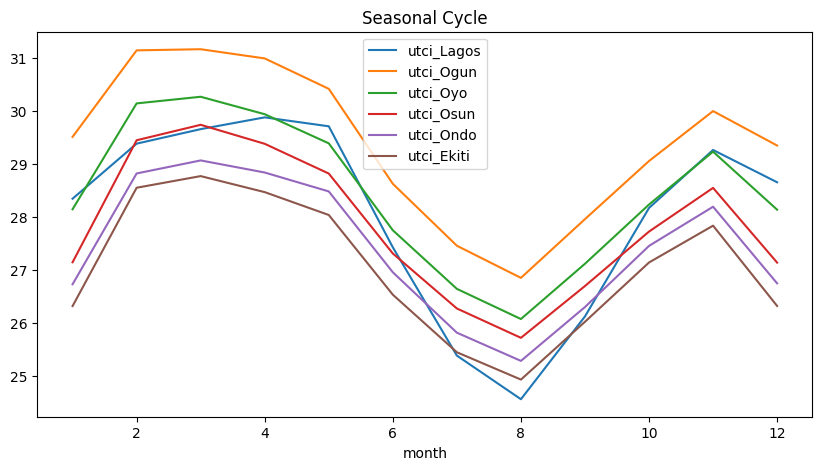

In [37]:
# month pattern
DF["month"] = DF["timestamp"].dt.month

monthly = DF.groupby("month")[variables].mean()

monthly.plot(figsize=(10,5))
plt.title("Seasonal Cycle")
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_16576\2590842432.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DF["month"] = DF["timestamp"].dt.month


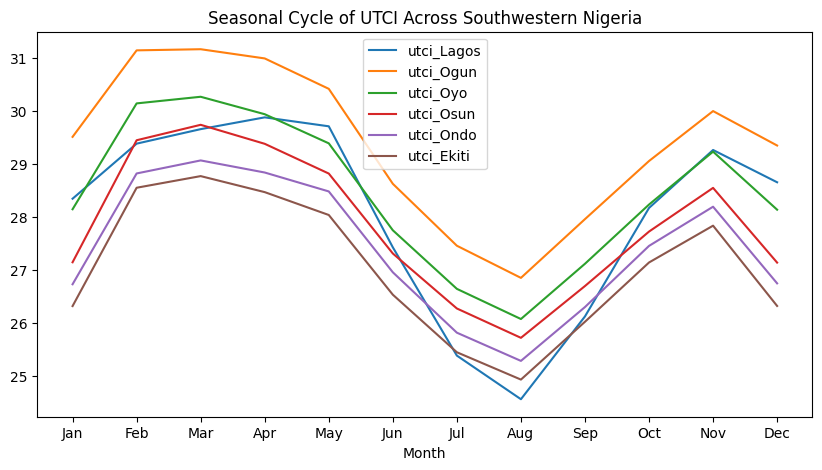

In [28]:
import calendar

# Extract month
DF["month"] = DF["timestamp"].dt.month

# Group
monthly = DF.groupby("month")[variables].mean()

# Convert to month names
monthly.index = [calendar.month_abbr[m] for m in monthly.index]

# Plot
ax = monthly.plot(figsize=(10,5))

# Force all months to show
ax.set_xticks(range(len(monthly.index)))
ax.set_xticklabels(monthly.index, rotation=0)

plt.title("Seasonal Cycle of UTCI Across Southwestern Nigeria")
plt.xlabel("Month")
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_16576\3554726295.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DF["year"] = DF["timestamp"].dt.year


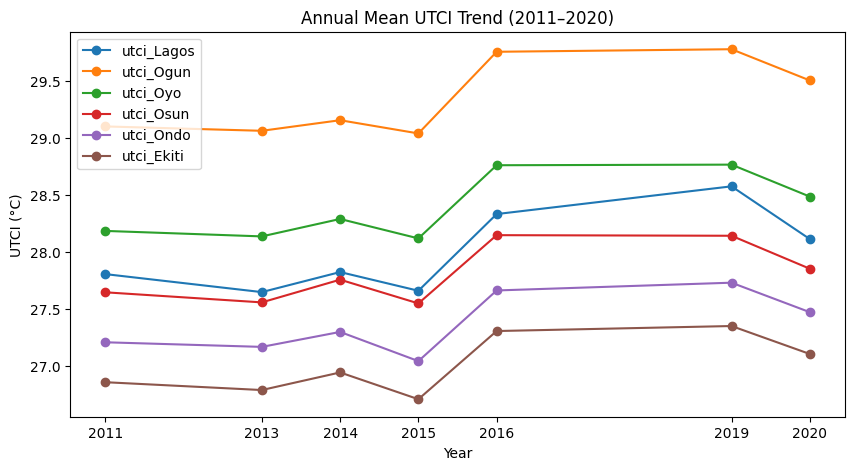

In [34]:
DF["year"] = DF["timestamp"].dt.year

yearly = DF.groupby("year")[variables].mean()

ax = yearly.plot(figsize=(10,5), marker='o')

# Force all years to display
ax.set_xticks(yearly.index)

plt.title("Annual Mean UTCI Trend (2011–2020)")
plt.xlabel("Year")
plt.ylabel("UTCI (°C)")
plt.show()

<Axes: xlabel='year'>

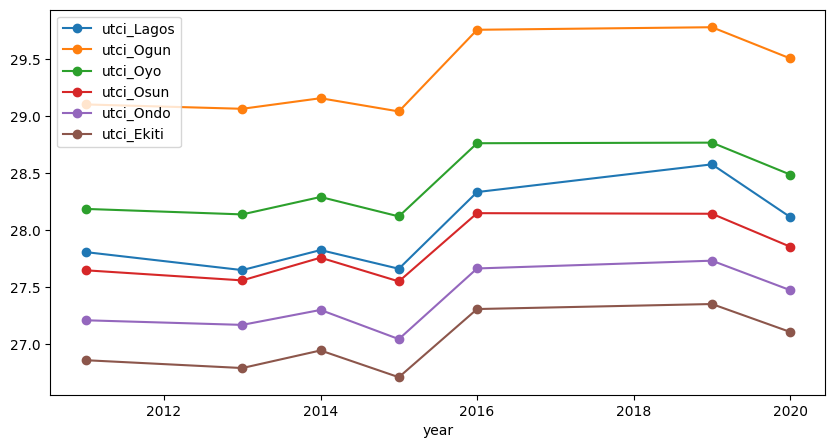

In [36]:
yearly.plot(figsize=(10,5), marker='o')

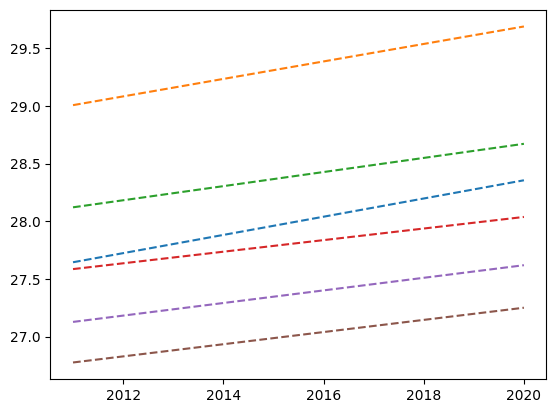

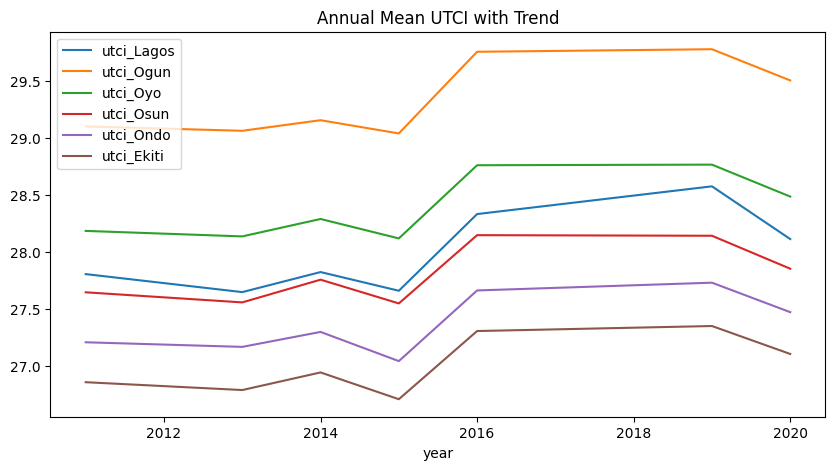

In [35]:
import numpy as np

for col in yearly.columns:
    z = np.polyfit(yearly.index, yearly[col], 1)
    p = np.poly1d(z)
    plt.plot(yearly.index, p(yearly.index), linestyle='--')

yearly.plot(figsize=(10,5))
plt.title("Annual Mean UTCI with Trend")
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_17124\3005948347.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DF['timestamp'] = pd.to_datetime(DF['timestamp'])
C:\Users\User\AppData\Local\Temp\ipykernel_17124\3005948347.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DF['month'] = DF['timestamp'].dt.month
C:\Users\User\anaconda3\envs\thermal_ml\lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'hori

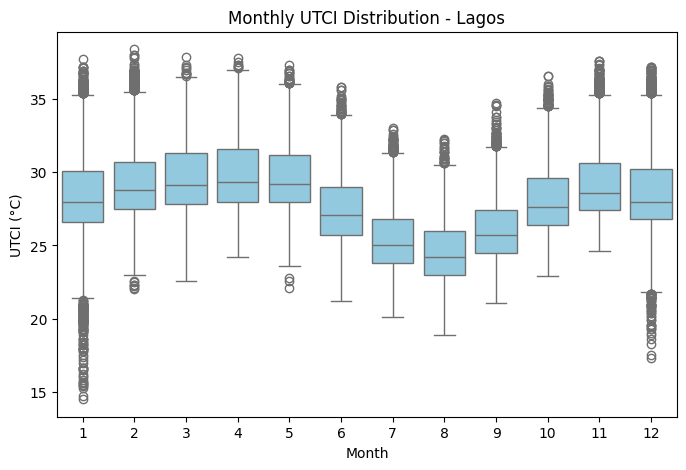

C:\Users\User\anaconda3\envs\thermal_ml\lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


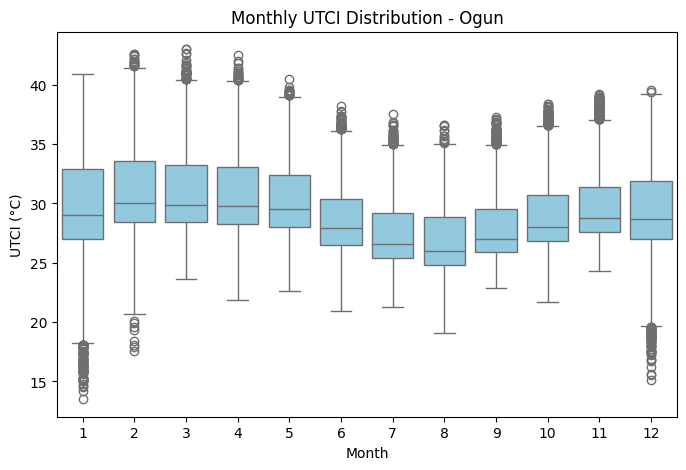

C:\Users\User\anaconda3\envs\thermal_ml\lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


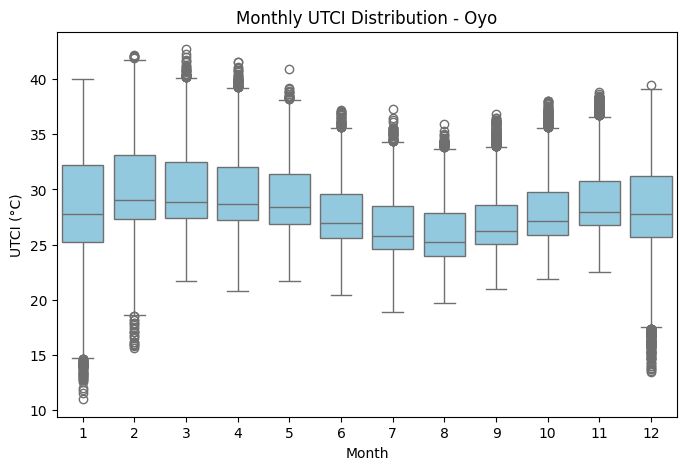

C:\Users\User\anaconda3\envs\thermal_ml\lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


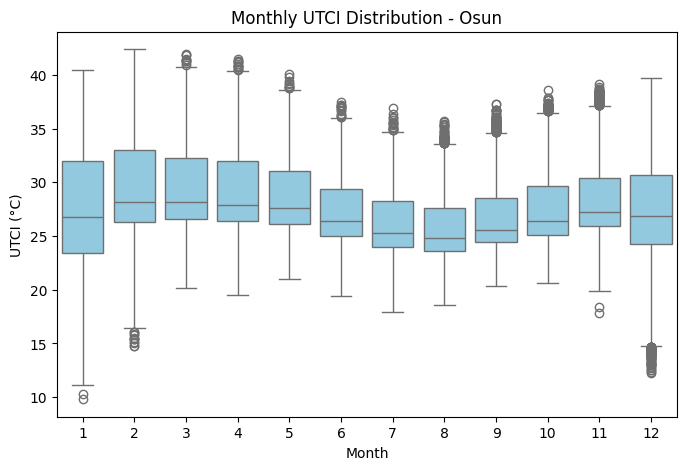

C:\Users\User\anaconda3\envs\thermal_ml\lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


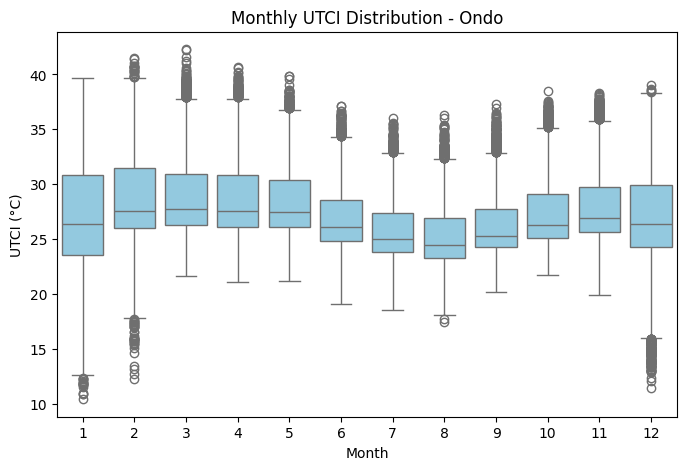

C:\Users\User\anaconda3\envs\thermal_ml\lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


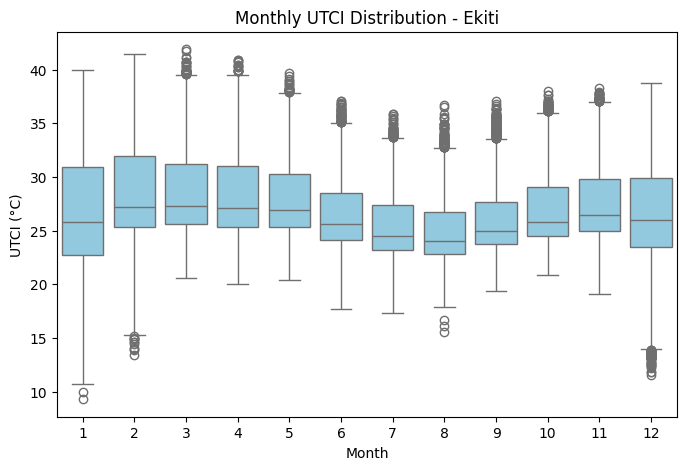

In [38]:
# 3. Monthly boxplots (seasonal cycle) of each variable across the region
# convert timestamp to datetime
DF['timestamp'] = pd.to_datetime(DF['timestamp'])

# extract month
DF['month'] = DF['timestamp'].dt.month

for var in variables:

    state = var.split("_")[1]

    plt.figure(figsize=(8,5))

    sns.boxplot(x='month', y=var, data=DF, color='skyblue')

    plt.title(f"Monthly UTCI Distribution - {state}")
    plt.xlabel("Month")
    plt.ylabel("UTCI (°C)")
    plt.show()

Numeric columns used for correlation: Index(['rh_Ekiti', 'rh_Lagos', 'rh_Ogun', 'rh_Ondo', 'rh_Osun', 'rh_Oyo',
       'sr_Ekiti', 'sr_Lagos', 'sr_Ogun', 'sr_Ondo', 'sr_Osun', 'sr_Oyo',
       'ta_Ekiti', 'ta_Lagos', 'ta_Ogun', 'ta_Ondo', 'ta_Osun', 'ta_Oyo',
       'ws_Ekiti', 'ws_Lagos', 'ws_Ogun', 'ws_Ondo', 'ws_Osun', 'ws_Oyo',
       'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'utci_Lagos', 'utci_Ogun',
       'utci_Oyo', 'utci_Osun', 'utci_Ondo', 'utci_Ekiti'],
      dtype='object')


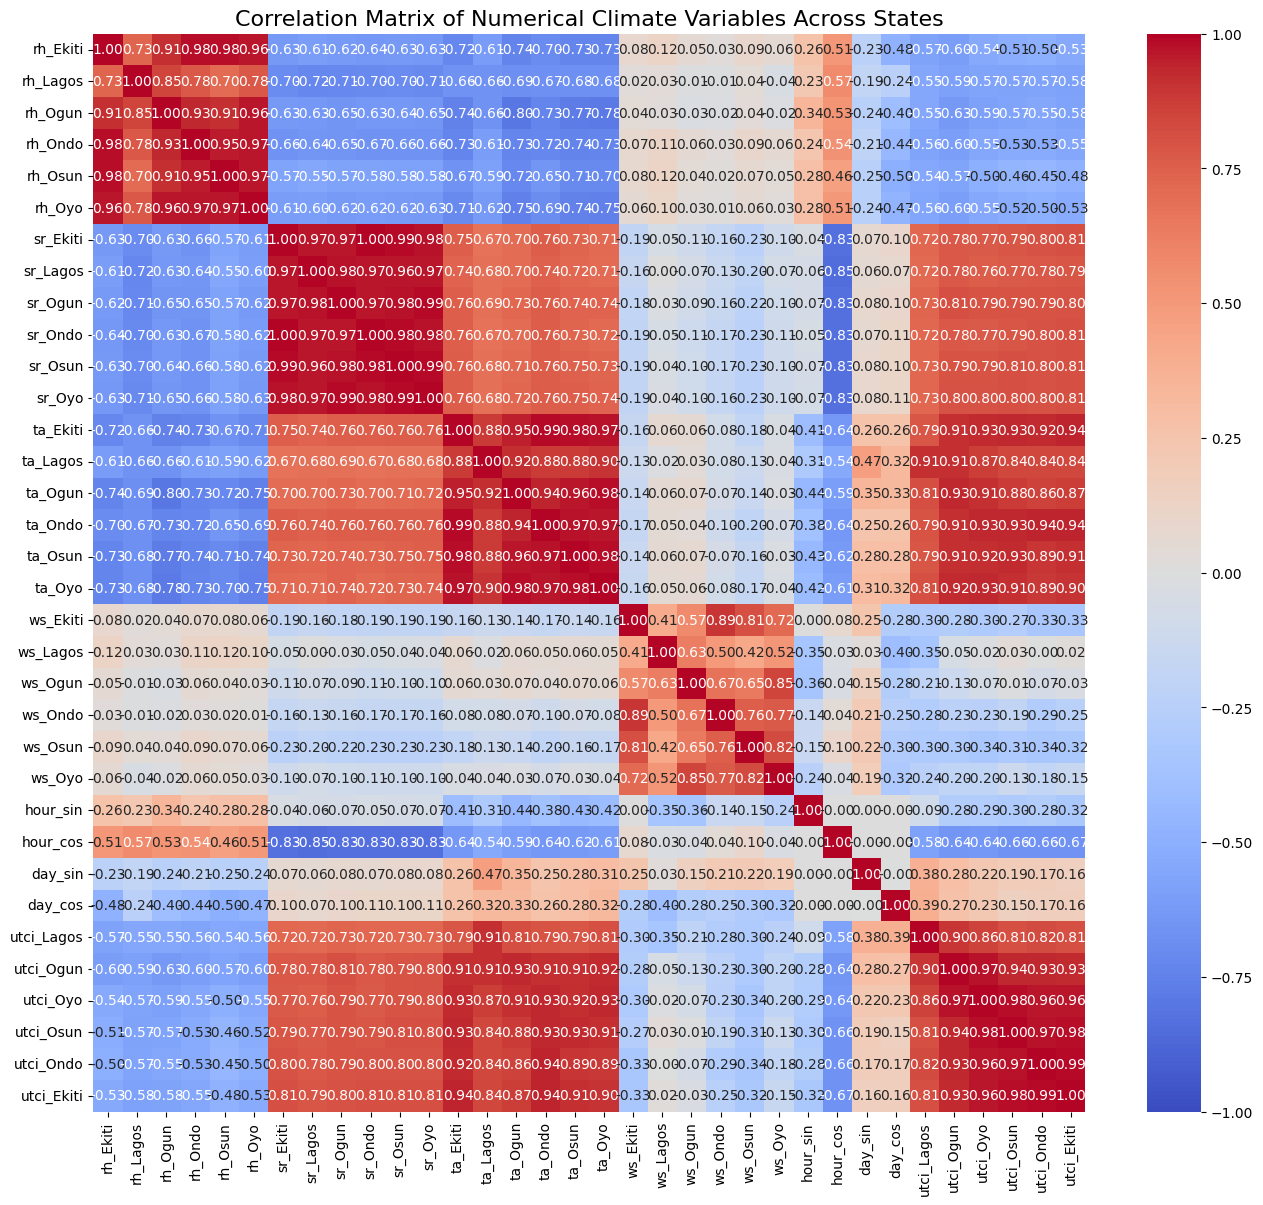

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Select all numeric columns (float or int) from DF
numeric_cols = DF.select_dtypes(include=['float32', 'float64', 'int64']).columns
print("Numeric columns used for correlation:", numeric_cols)

# 2. Compute correlation matrix
corr_matrix = DF[numeric_cols].corr()

# 3. Plot heatmap
plt.figure(figsize=(16,14))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix of Numerical Climate Variables Across States", fontsize=16)
plt.show()

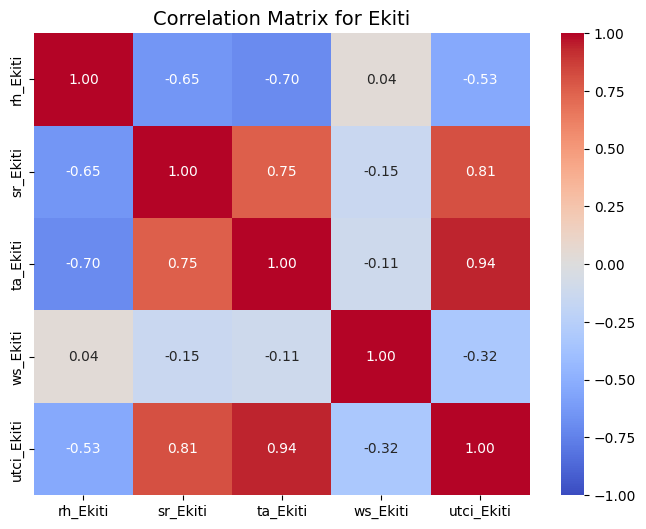

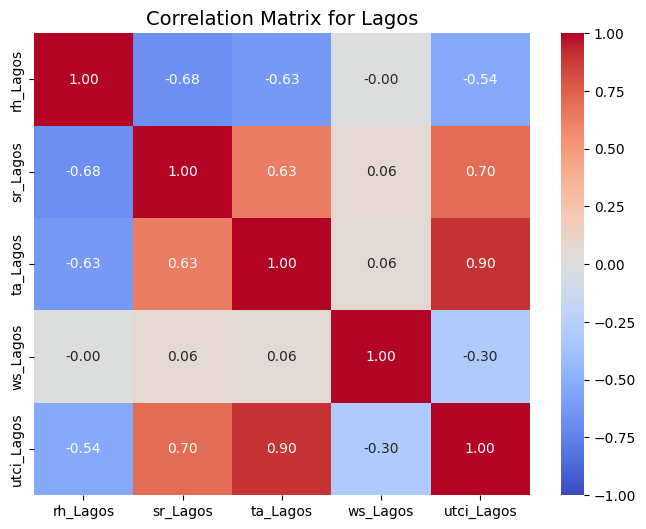

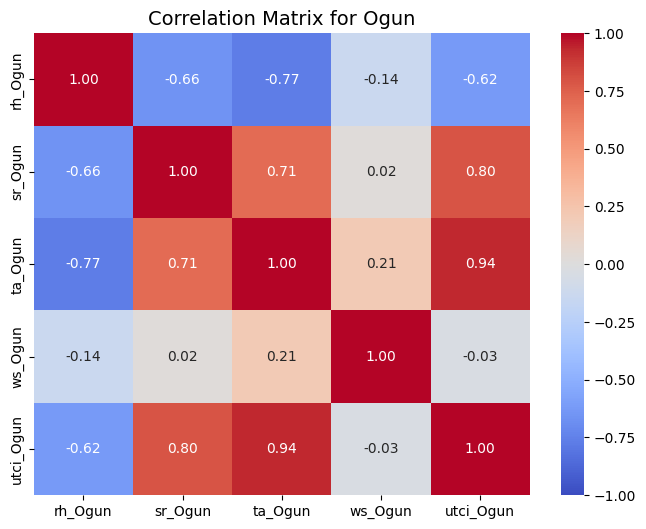

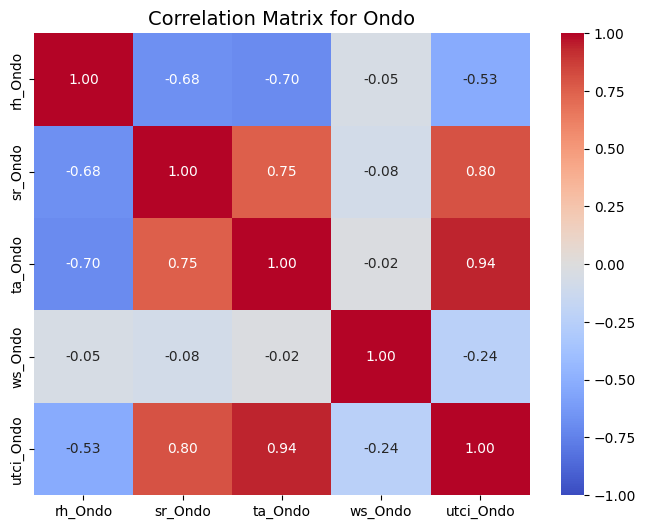

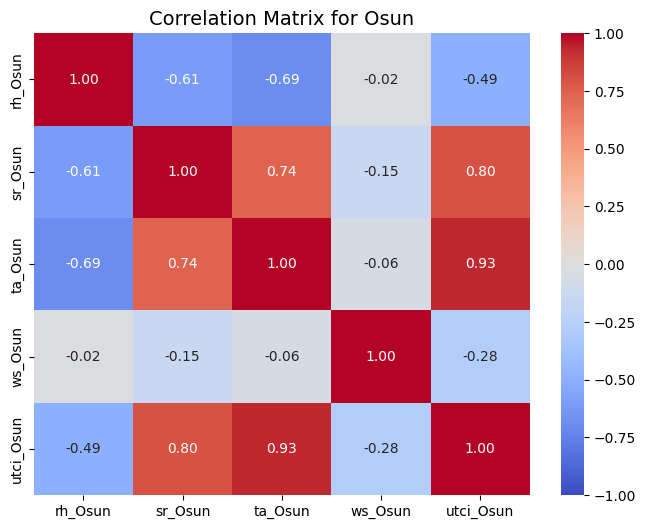

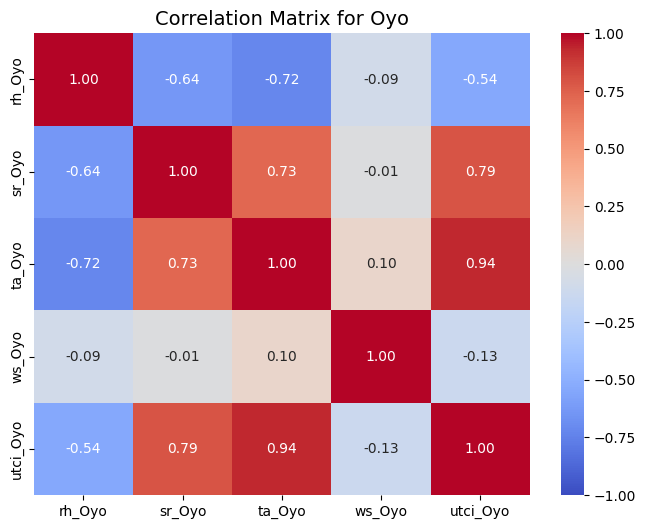

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of states in your dataset
states = ['Ekiti', 'Lagos', 'Ogun', 'Ondo', 'Osun', 'Oyo']

for state in states:
    # Select columns that end with the state name
    state_cols = [col for col in DF.columns if col.endswith(f"_{state}")]
    
    # Compute correlation matrix for this state
    corr_matrix = DF[state_cols].corr()
    
    # Plot heatmap
    plt.figure(figsize=(8,6))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(f"Correlation Matrix for {state}", fontsize=14)
    plt.show()

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) was conducted to understand the statistical characteristics of the meteorological variables and the derived thermal comfort index prior to model development. The analysis focused on examining variable distributions, identifying relationships among predictors, and detecting temporal patterns in outdoor thermal comfort conditions across Southwestern Nigeria.

## Distribution of Meteorological Variables

Figure 1 presents example distribution plots of key meteorological variables used in the modeling framework. Each variable was visualized using histograms combined with kernel density estimation (KDE) curves to reveal both the frequency distribution and underlying probability density structure.

**Figure 1. Example distributions of meteorological variables (histogram with KDE overlay).**

The distribution of **air temperature** exhibits an approximately bell-shaped profile, with most observations concentrated within a typical tropical temperature range. Slight positive skewness is present due to occasional extreme heat events. These high-temperature values are particularly relevant for thermal comfort modeling because they correspond to periods of elevated thermal stress.

The distribution of **relative humidity** indicates persistently high moisture levels across the region, reflecting the humid tropical climate of Southwestern Nigeria. Relative humidity values frequently exceed 70%, which has important implications for human thermal comfort because high atmospheric moisture reduces the efficiency of evaporative cooling from the human body.

The **wind speed** distribution shows that most observations fall within low-to-moderate wind conditions. This pattern is typical of tropical environments where large-scale atmospheric circulation often produces relatively calm surface conditions. Despite their modest magnitude, wind speeds remain important for thermal comfort because convective heat transfer increases with airflow.

The **solar radiation** distribution is strongly positively skewed, with a large number of low values corresponding to nighttime hours and cloudy conditions. High radiation values occur during clear daytime periods and contribute significantly to radiant heat exposure.

Overall, the distribution plots confirm that the meteorological variables fall within physically plausible ranges and exhibit patterns consistent with tropical climate dynamics.

## Distribution of Thermal Comfort Index (UTCI)

The notebook also visualizes the distribution of the Universal Thermal Climate Index (UTCI) for each state using overlapping kernel density curves. These distributions provide insight into the range and variability of thermal comfort conditions across the study region.

The resulting density curves indicate that all six states exhibit broadly similar UTCI ranges, reflecting the influence of regional-scale climate patterns. However, subtle differences are visible among states. For example, Lagos and Ondo—both coastal states—display slightly narrower distributions, likely due to moderating influences from maritime air masses and persistent humidity.

In contrast, inland states such as Oyo exhibit slightly broader distributions of UTCI values. This pattern may reflect greater diurnal temperature variability associated with inland climatic conditions and reduced oceanic influence.

These findings highlight that while hourly thermal comfort conditions fluctuate considerably, the overall thermal stress range remains relatively consistent across neighboring states.

## Correlation Analysis

To examine relationships among variables, Pearson correlation coefficients were computed and visualized using heatmaps.

**Figure 2. Correlation heatmap of meteorological variables and UTCI values.**

Two separate heatmaps were produced:

1. Correlation among meteorological predictors
2. Correlation among UTCI values across states

The feature correlation heatmap reveals several expected relationships between atmospheric variables. Air temperature shows a strong positive correlation with solar radiation, reflecting the direct influence of incoming solar energy on surface heating. Relative humidity displays a moderate negative correlation with air temperature, which is typical in tropical climates where warmer air tends to reduce relative humidity values for a given moisture content.

Wind speed exhibits relatively weak correlations with other variables, indicating that wind behavior is largely independent of temperature and radiation patterns within the dataset.

The second heatmap examines correlations among UTCI values across the six states. The results reveal extremely high correlations—often approaching unity—between states. This indicates that thermal comfort conditions are largely governed by regional atmospheric patterns affecting the entire Southwestern Nigerian climate system simultaneously.

While these high correlations demonstrate consistent regional climate behavior, they also suggest potential collinearity issues for linear regression models. In contrast, tree-based machine learning algorithms are generally more robust to such redundancy in input variables.

## Temporal Patterns in Thermal Comfort

Temporal analysis was conducted to examine how thermal comfort conditions vary over daily and seasonal timescales.

### Diurnal Cycle

The notebook computes average UTCI values for each hour of the day to reveal typical diurnal patterns in thermal comfort conditions. The resulting curve shows a smooth increase in UTCI values following sunrise, reaching peak levels during early afternoon hours between approximately 14:00 and 15:00 local time.

During early morning hours, UTCI values are generally lowest, corresponding to cooler temperatures and reduced solar radiation. As the day progresses, increasing solar radiation and rising air temperature contribute to a rapid increase in thermal stress. After sunset, the reduction in solar heating leads to a gradual decline in UTCI values.

The resulting diurnal pattern resembles a sinusoidal curve, reflecting the strong influence of the daily solar cycle on human thermal perception.

### Seasonal Variation

Seasonal variation in thermal comfort conditions was also analyzed by calculating monthly average UTCI values. The results indicate that thermal stress is highest during the **late dry season**, particularly between February and March. During this period, clear skies and intense solar radiation produce elevated temperatures and high radiant heat loads.

Conversely, the lowest UTCI values occur during the **rainy season**, particularly between July and September. Increased cloud cover during these months reduces solar radiation and limits daytime heating, leading to more moderate thermal comfort conditions.

Monthly boxplots reveal that variability in UTCI is greatest during seasonal transition periods. These months experience fluctuating weather patterns that produce larger variability in atmospheric conditions.

These seasonal trends align with established climatological patterns for tropical West Africa.


## Statistical Significance and Potential Biases

Given the large size of the ERA5-derived dataset, many of the observed relationships and patterns are statistically significant. However, several methodological limitations must be acknowledged.

First, the analysis relies on meteorological data extracted from grid cells representing state capitals. This spatial sampling approach captures urban-scale climate conditions but does not account for microclimatic variability within each state. Local factors such as vegetation cover, urban density, and surface materials may therefore influence thermal comfort conditions at finer spatial scales.

Second, the estimation of mean radiant temperature relies on an approximate relationship based on air temperature and solar radiation. This simplification assumes a constant proportion of solar heating and does not fully capture complex radiative interactions between buildings, surfaces, and the atmosphere.

Consequently, the resulting UTCI values should be interpreted as **approximations of regional thermal comfort conditions rather than precise local measurements**.

Despite these limitations, the exploratory analysis confirms that the dataset captures realistic meteorological behavior and provides a robust foundation for machine learning modeling.

## Time-Aware Data Splitting

In [22]:
DF

,timestamp,rh_Ekiti,rh_Lagos,rh_Ogun,rh_Ondo,rh_Osun,rh_Oyo,sr_Ekiti,sr_Lagos,sr_Ogun,...,hour_sin,hour_cos,day_sin,day_cos,utci_Lagos,utci_Ogun,utci_Oyo,utci_Osun,utci_Ondo,utci_Ekiti
0,2011-01-01 00:00:00,42.434970,69.339358,71.252682,54.043706,38.990827,58.555304,0.0,0.0,0.0,...,0.000000,1.000000,0.000000e+00,1.0,26.8,21.0,17.7,17.0,15.7,16.2
1,2011-01-01 01:00:00,41.242659,75.077924,73.091526,49.356117,37.486534,56.313946,0.0,0.0,0.0,...,0.258819,0.965926,0.000000e+00,1.0,24.2,21.1,16.6,17.0,15.6,16.2
2,2011-01-01 02:00:00,41.515831,78.058054,74.642361,50.580577,37.740212,51.636660,0.0,0.0,0.0,...,0.500000,0.866025,0.000000e+00,1.0,22.9,20.2,15.5,16.3,14.7,15.6
3,2011-01-01 03:00:00,37.972071,76.310596,69.727706,41.792023,34.218000,42.207692,0.0,0.0,0.0,...,0.707107,0.707107,0.000000e+00,1.0,20.9,16.7,12.0,12.9,12.1,12.4
4,2011-01-01 04:00:00,38.487609,75.951497,68.542576,41.274952,34.400217,35.885450,0.0,0.0,0.0,...,0.866025,0.500000,0.000000e+00,1.0,20.3,16.0,11.8,12.6,11.7,11.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87126,2020-12-31 19:00:00,51.029875,82.284763,63.796043,59.460032,39.632017,53.987061,0.0,0.0,0.0,...,-0.965926,0.258819,6.432491e-16,1.0,28.2,29.7,29.2,29.0,27.3,28.2
87127,2020-12-31 20:00:00,72.099848,85.926341,77.105324,76.101753,58.493294,72.926495,0.0,0.0,0.0,...,-0.866025,0.500000,6.432491e-16,1.0,27.9,28.4,27.3,26.6,25.9,26.1
87128,2020-12-31 21:00:00,75.400886,87.054258,82.229323,81.607035,75.397755,81.677406,0.0,0.0,0.0,...,-0.707107,0.707107,6.432491e-16,1.0,27.9,28.7,27.8,26.6,26.9,26.4
87129,2020-12-31 22:00:00,81.914958,89.507877,88.832043,86.947565,83.015257,92.022992,0.0,0.0,0.0,...,-0.500000,0.866025,6.432491e-16,1.0,27.4,28.3,27.1,24.1,25.6,25.0


In [36]:
DF = DF.reset_index(drop=True)

In [39]:
DF

,timestamp,rh_Ekiti,rh_Lagos,rh_Ogun,rh_Ondo,rh_Osun,rh_Oyo,sr_Ekiti,sr_Lagos,sr_Ogun,...,hour_sin,hour_cos,day_sin,day_cos,utci_Lagos,utci_Ogun,utci_Oyo,utci_Osun,utci_Ondo,utci_Ekiti
1970-01-01 00:00:00.000000000,2011-01-01 00:00:00,42.434970,69.339358,71.252682,54.043706,38.990827,58.555304,0.0,0.0,0.0,...,0.000000,1.000000,0.000000e+00,1.0,26.8,21.0,17.7,17.0,15.7,16.2
1970-01-01 00:00:00.000000001,2011-01-01 01:00:00,41.242659,75.077924,73.091526,49.356117,37.486534,56.313946,0.0,0.0,0.0,...,0.258819,0.965926,0.000000e+00,1.0,24.2,21.1,16.6,17.0,15.6,16.2
1970-01-01 00:00:00.000000002,2011-01-01 02:00:00,41.515831,78.058054,74.642361,50.580577,37.740212,51.636660,0.0,0.0,0.0,...,0.500000,0.866025,0.000000e+00,1.0,22.9,20.2,15.5,16.3,14.7,15.6
1970-01-01 00:00:00.000000003,2011-01-01 03:00:00,37.972071,76.310596,69.727706,41.792023,34.218000,42.207692,0.0,0.0,0.0,...,0.707107,0.707107,0.000000e+00,1.0,20.9,16.7,12.0,12.9,12.1,12.4
1970-01-01 00:00:00.000000004,2011-01-01 04:00:00,38.487609,75.951497,68.542576,41.274952,34.400217,35.885450,0.0,0.0,0.0,...,0.866025,0.500000,0.000000e+00,1.0,20.3,16.0,11.8,12.6,11.7,11.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1970-01-01 00:00:00.000056245,2020-12-31 19:00:00,51.029875,82.284763,63.796043,59.460032,39.632017,53.987061,0.0,0.0,0.0,...,-0.965926,0.258819,6.432491e-16,1.0,28.2,29.7,29.2,29.0,27.3,28.2
1970-01-01 00:00:00.000056246,2020-12-31 20:00:00,72.099848,85.926341,77.105324,76.101753,58.493294,72.926495,0.0,0.0,0.0,...,-0.866025,0.500000,6.432491e-16,1.0,27.9,28.4,27.3,26.6,25.9,26.1
1970-01-01 00:00:00.000056247,2020-12-31 21:00:00,75.400886,87.054258,82.229323,81.607035,75.397755,81.677406,0.0,0.0,0.0,...,-0.707107,0.707107,6.432491e-16,1.0,27.9,28.7,27.8,26.6,26.9,26.4
1970-01-01 00:00:00.000056248,2020-12-31 22:00:00,81.914958,89.507877,88.832043,86.947565,83.015257,92.022992,0.0,0.0,0.0,...,-0.500000,0.866025,6.432491e-16,1.0,27.4,28.3,27.1,24.1,25.6,25.0


In [40]:
DF = DF.reset_index(drop=True)


In [42]:
DF

,timestamp,rh_Ekiti,rh_Lagos,rh_Ogun,rh_Ondo,rh_Osun,rh_Oyo,sr_Ekiti,sr_Lagos,sr_Ogun,...,hour_sin,hour_cos,day_sin,day_cos,utci_Lagos,utci_Ogun,utci_Oyo,utci_Osun,utci_Ondo,utci_Ekiti
0,2011-01-01 00:00:00,42.434970,69.339358,71.252682,54.043706,38.990827,58.555304,0.0,0.0,0.0,...,0.000000,1.000000,0.000000e+00,1.0,26.8,21.0,17.7,17.0,15.7,16.2
1,2011-01-01 01:00:00,41.242659,75.077924,73.091526,49.356117,37.486534,56.313946,0.0,0.0,0.0,...,0.258819,0.965926,0.000000e+00,1.0,24.2,21.1,16.6,17.0,15.6,16.2
2,2011-01-01 02:00:00,41.515831,78.058054,74.642361,50.580577,37.740212,51.636660,0.0,0.0,0.0,...,0.500000,0.866025,0.000000e+00,1.0,22.9,20.2,15.5,16.3,14.7,15.6
3,2011-01-01 03:00:00,37.972071,76.310596,69.727706,41.792023,34.218000,42.207692,0.0,0.0,0.0,...,0.707107,0.707107,0.000000e+00,1.0,20.9,16.7,12.0,12.9,12.1,12.4
4,2011-01-01 04:00:00,38.487609,75.951497,68.542576,41.274952,34.400217,35.885450,0.0,0.0,0.0,...,0.866025,0.500000,0.000000e+00,1.0,20.3,16.0,11.8,12.6,11.7,11.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56245,2020-12-31 19:00:00,51.029875,82.284763,63.796043,59.460032,39.632017,53.987061,0.0,0.0,0.0,...,-0.965926,0.258819,6.432491e-16,1.0,28.2,29.7,29.2,29.0,27.3,28.2
56246,2020-12-31 20:00:00,72.099848,85.926341,77.105324,76.101753,58.493294,72.926495,0.0,0.0,0.0,...,-0.866025,0.500000,6.432491e-16,1.0,27.9,28.4,27.3,26.6,25.9,26.1
56247,2020-12-31 21:00:00,75.400886,87.054258,82.229323,81.607035,75.397755,81.677406,0.0,0.0,0.0,...,-0.707107,0.707107,6.432491e-16,1.0,27.9,28.7,27.8,26.6,26.9,26.4
56248,2020-12-31 22:00:00,81.914958,89.507877,88.832043,86.947565,83.015257,92.022992,0.0,0.0,0.0,...,-0.500000,0.866025,6.432491e-16,1.0,27.4,28.3,27.1,24.1,25.6,25.0


In [23]:
# Convert timestamp column
DF["timestamp"] = pd.to_datetime(DF["timestamp"])

# Sort by timestamp
DF = DF.sort_values("timestamp")

# Set timestamp as index
DF = DF.set_index("timestamp")

# Split by year
train = DF.loc["2011":"2018"]
val   = DF.loc["2019":"2019"]
test  = DF.loc["2020":"2020"]

print("Train:", train.shape)
print("Val:", val.shape)
print("Test:", test.shape)

Train: (40351, 36)
Val: (7866, 36)
Test: (8033, 36)


C:\Users\User\AppData\Local\Temp\ipykernel_3932\4265409654.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DF["timestamp"] = pd.to_datetime(DF["timestamp"])


In [24]:
import os

# Create folders if they do not exist
os.makedirs("tables", exist_ok=True)
os.makedirs("figures", exist_ok=True)
os.makedirs("splits", exist_ok=True)

print("Folders created or already exist.")

Folders created or already exist.


In [25]:
split_summary = pd.DataFrame({
    "split": ["train", "val", "test"],
    "rows": [len(train), len(val), len(test)],
    "start": [train.index.min(), val.index.min(), test.index.min()],
    "end": [train.index.max(), val.index.max(), test.index.max()]
})

split_summary.to_csv("tables/split_summary.csv", index=False)
split_summary

,split,rows,start,end
0,train,40351,2011-01-01,2016-12-31 23:00:00
1,val,7866,2019-01-01,2019-12-31 23:00:00
2,test,8033,2020-01-01,2020-12-31 23:00:00


## Prepare Modeling Dataset for ALL States

In [26]:
# Reproducibility
SEED = 42

# Core libraries
import numpy as np
import pandas as pd

# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Scaling
from sklearn.preprocessing import StandardScaler

# XGBoost
from xgboost import XGBRegressor

# Hyperparameter tuning
import optuna

In [27]:
states = ["Lagos","Ogun","Oyo","Osun","Ondo","Ekiti"]

all_results = []

for state in states:

    print("Processing:", state)

    TARGET = f"utci_{state}"

    features = [
        col for col in train.columns
        if col.startswith((f"ta_{state}", f"rh_{state}", f"ws_{state}", f"sr_{state}"))
        or col.startswith(("hour_","day_"))
    ]

    X_train = train[features]
    y_train = train[TARGET]

    X_val = val[features]
    y_val = val[TARGET]

    X_test = test[features]
    y_test = test[TARGET]

    # scale for ANN
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    pred_dict = {
        "Linear": LinearRegression().fit(X_train, y_train).predict(X_test),
        "DecisionTree": DecisionTreeRegressor(random_state=SEED).fit(X_train, y_train).predict(X_test),
        "RandomForest": RandomForestRegressor(random_state=SEED).fit(X_train, y_train).predict(X_test),
        "XGBoost": XGBRegressor(objective="reg:squarederror", random_state=SEED).fit(X_train, y_train).predict(X_test),
        "ANN": MLPRegressor(max_iter=500, random_state=SEED).fit(X_train_scaled, y_train).predict(X_test_scaled)
    }

    for name, pred in pred_dict.items():

        all_results.append({
            "State": state,
            "Model": name,
            "MAE": mean_absolute_error(y_test, pred),
            "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
            "R2": r2_score(y_test, pred)
        })

Processing: Lagos
Processing: Ogun
Processing: Oyo
Processing: Osun
Processing: Ondo
Processing: Ekiti


In [51]:
states = ["Lagos","Ogun","Oyo","Osun","Ondo","Ekiti"]

all_results = []
all_predictions = []   
all_models = {}     

for state in states:

    print("Processing:", state)

    TARGET = f"utci_{state}"

    features = [
        col for col in train.columns
        if col.startswith((f"ta_{state}", f"rh_{state}", f"ws_{state}", f"sr_{state}"))
        or col.startswith(("hour_","day_"))
    ]

    X_train = train[features]
    y_train = train[TARGET]

    X_test = test[features]
    y_test = test[TARGET]

    # scale for ANN
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # TRAIN MODELS (STORE THEM)
    models = {
        "Linear": LinearRegression().fit(X_train, y_train),
        "DecisionTree": DecisionTreeRegressor(random_state=SEED).fit(X_train, y_train),
        "RandomForest": RandomForestRegressor(random_state=SEED).fit(X_train, y_train),
        "XGBoost": XGBRegressor(objective="reg:squarederror", random_state=SEED).fit(X_train, y_train),
        "ANN": MLPRegressor(max_iter=500, random_state=SEED).fit(X_train_scaled, y_train)
    }

    for name, model in models.items():

        if name == "ANN":
            pred = model.predict(X_test_scaled)
        else:
            pred = model.predict(X_test)

        # Save results
        all_results.append({
            "State": state,
            "Model": name,
            "MAE": mean_absolute_error(y_test, pred),
            "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
            "R2": r2_score(y_test, pred)
        })

        # Save predictions for plotting
        all_predictions.append({
            "State": state,
            "Model": name,
            "y_test": y_test.values,
            "y_pred": pred
        })

    # Save models 
    all_models[state] = models

Processing: Lagos
Processing: Ogun
Processing: Oyo
Processing: Osun
Processing: Ondo
Processing: Ekiti


In [54]:
results_df = pd.DataFrame(all_results)
pred_df = pd.DataFrame(all_predictions)

In [29]:
results_df = pd.DataFrame(all_results)

results_df = results_df.sort_values(
    ["State","RMSE"]
).reset_index(drop=True)

results_df

,State,Model,MAE,RMSE,R2
0,Ekiti,ANN,0.059425,0.078436,0.999708
1,Ekiti,XGBoost,0.142167,0.231746,0.997447
2,Ekiti,RandomForest,0.151865,0.251858,0.996985
3,Ekiti,Linear,0.195259,0.263861,0.996690
4,Ekiti,DecisionTree,0.267770,0.413247,0.991882
5,Lagos,ANN,0.060982,0.079574,0.999422
6,Lagos,XGBoost,0.125601,0.190535,0.996687
7,Lagos,Linear,0.159051,0.228833,0.995221
8,Lagos,RandomForest,0.136137,0.245716,0.994490
9,Lagos,DecisionTree,0.230636,0.361307,0.988087


In [30]:
best_models = results_df.loc[
    results_df.groupby("State")["RMSE"].idxmin()
]

best_models[["State","Model","RMSE"]]

,State,Model,RMSE
0,Ekiti,ANN,0.078436
5,Lagos,ANN,0.079574
10,Ogun,ANN,0.087931
15,Ondo,ANN,0.082769
20,Osun,ANN,0.086195
25,Oyo,ANN,0.085620


In [57]:
results_df.to_csv(
    "all_models_all_states_results.csv",
    index=False
)

best_models.to_csv(
    "best_model_per_state.csv",
    index=False
)

## Hyperparameter Tuning for All States

In [31]:
for state in states:

    print("Tuning models for:", state)

    TARGET = f"utci_{state}"

    features = [
        col for col in train.columns
        if col.startswith((f"ta_{state}",f"rh_{state}",f"ws_{state}",f"sr_{state}"))
        or col.startswith(("hour_","day_"))
    ]

    X_train = train[features]
    y_train = train[TARGET]

    X_val = val[features]
    y_val = val[TARGET]

    X_test = test[features]
    y_test = test[TARGET]

    # scaling for ANN
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    # RandomForest Tuning

    def objective_rf(trial):

        params = {
            "n_estimators": trial.suggest_int("n_estimators",50,250),
            "max_depth": trial.suggest_int("max_depth",3,20),
            "min_samples_split": trial.suggest_int("min_samples_split",2,10),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf",1,5),
            "random_state": SEED,
            "n_jobs": -1
        }

        model = RandomForestRegressor(**params)

        model.fit(X_train,y_train)

        pred = model.predict(X_val)

        return np.sqrt(mean_squared_error(y_val,pred))


    study_rf = optuna.create_study(direction="minimize")

    study_rf.optimize(objective_rf,n_trials=30)

    best_rf = RandomForestRegressor(
        **study_rf.best_params,
        random_state=SEED,
        n_jobs=-1
    )

    best_rf.fit(
        pd.concat([X_train,X_val]),
        pd.concat([y_train,y_val])
    )

    pred_rf_tuned = best_rf.predict(X_test)


    # XGBoost Tuning
    def objective_xgb(trial):

        params = {
            "n_estimators": trial.suggest_int("n_estimators",50,300),
            "max_depth": trial.suggest_int("max_depth",3,12),
            "learning_rate": trial.suggest_float("learning_rate",0.01,0.3,log=True),
            "subsample": trial.suggest_float("subsample",0.6,1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree",0.6,1.0),
            "random_state": SEED,
            "objective":"reg:squarederror"
        }

        model = XGBRegressor(**params)

        model.fit(X_train,y_train)

        pred = model.predict(X_val)

        return np.sqrt(mean_squared_error(y_val,pred))


    study_xgb = optuna.create_study(direction="minimize")

    study_xgb.optimize(objective_xgb,n_trials=30)

    best_xgb = XGBRegressor(
        **study_xgb.best_params,
        random_state=SEED,
        objective="reg:squarederror"
    )

    best_xgb.fit(
        pd.concat([X_train,X_val]),
        pd.concat([y_train,y_val])
    )

    pred_xgb_tuned = best_xgb.predict(X_test)


    # ANN Tuning

    def objective_ann(trial):

        n_hidden = trial.suggest_int("n_hidden",1,3)

        hidden_layers = tuple(
            trial.suggest_int(f"n_units_l{i}",16,128)
            for i in range(n_hidden)
        )

        alpha = trial.suggest_float("alpha",1e-6,1e-2,log=True)

        lr = trial.suggest_float("learning_rate_init",1e-4,1e-2,log=True)

        model = MLPRegressor(
            hidden_layer_sizes=hidden_layers,
            alpha=alpha,
            learning_rate_init=lr,
            max_iter=500,
            random_state=SEED
        )

        model.fit(X_train_scaled,y_train)

        pred = model.predict(X_val_scaled)

        return np.sqrt(mean_squared_error(y_val,pred))


    study_ann = optuna.create_study(direction="minimize")

    study_ann.optimize(objective_ann,n_trials=30)

    best_params = study_ann.best_params

    hidden_layers = tuple(
        best_params[f"n_units_l{i}"]
        for i in range(best_params["n_hidden"])
    )

    best_ann = MLPRegressor(
        hidden_layer_sizes=hidden_layers,
        alpha=best_params["alpha"],
        learning_rate_init=best_params["learning_rate_init"],
        max_iter=500,
        random_state=SEED
    )

    best_ann.fit(
        np.vstack([X_train_scaled,X_val_scaled]),
        np.hstack([y_train,y_val])
    )

    pred_ann_tuned = best_ann.predict(X_test_scaled)


    # Save tuned results
    tuned_preds = {
        "RandomForest_Tuned": pred_rf_tuned,
        "XGBoost_Tuned": pred_xgb_tuned,
        "ANN_Tuned": pred_ann_tuned
    }

    for name,pred in tuned_preds.items():

        all_results.append({
            "State":state,
            "Model":name,
            "MAE":mean_absolute_error(y_test,pred),
            "RMSE":np.sqrt(mean_squared_error(y_test,pred)),
            "R2":r2_score(y_test,pred)
        })

[I 2026-03-19 23:00:07,302] A new study created in memory with name: no-name-77f89e1e-cecf-4285-ad59-d0f94b9c94eb


Tuning models for: Lagos


[I 2026-03-19 23:00:28,833] Trial 0 finished with value: 0.26297743839860865 and parameters: {'n_estimators': 203, 'max_depth': 11, 'min_samples_split': 5, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.26297743839860865.
[I 2026-03-19 23:00:49,098] Trial 1 finished with value: 0.1910816945271688 and parameters: {'n_estimators': 148, 'max_depth': 19, 'min_samples_split': 4, 'min_samples_leaf': 2}. Best is trial 1 with value: 0.1910816945271688.
[I 2026-03-19 23:01:07,401] Trial 2 finished with value: 0.19960604743097213 and parameters: {'n_estimators': 148, 'max_depth': 15, 'min_samples_split': 8, 'min_samples_leaf': 2}. Best is trial 1 with value: 0.1910816945271688.
[I 2026-03-19 23:01:12,938] Trial 3 finished with value: 1.2367597655862441 and parameters: {'n_estimators': 174, 'max_depth': 3, 'min_samples_split': 10, 'min_samples_leaf': 3}. Best is trial 1 with value: 0.1910816945271688.
[I 2026-03-19 23:01:25,982] Trial 4 finished with value: 0.23446602039591194 and paramete

Tuning models for: Ogun


[I 2026-03-19 23:27:41,720] Trial 0 finished with value: 0.6709101375415947 and parameters: {'n_estimators': 94, 'max_depth': 6, 'min_samples_split': 9, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.6709101375415947.
[I 2026-03-19 23:27:57,566] Trial 1 finished with value: 0.48189432313325253 and parameters: {'n_estimators': 156, 'max_depth': 8, 'min_samples_split': 10, 'min_samples_leaf': 1}. Best is trial 1 with value: 0.48189432313325253.
[I 2026-03-19 23:28:06,511] Trial 2 finished with value: 0.288555492296386 and parameters: {'n_estimators': 60, 'max_depth': 11, 'min_samples_split': 3, 'min_samples_leaf': 4}. Best is trial 2 with value: 0.288555492296386.
[I 2026-03-19 23:28:20,356] Trial 3 finished with value: 0.40341558193348115 and parameters: {'n_estimators': 158, 'max_depth': 9, 'min_samples_split': 4, 'min_samples_leaf': 2}. Best is trial 2 with value: 0.288555492296386.
[I 2026-03-19 23:28:26,917] Trial 4 finished with value: 1.208199238316447 and parameters: {'n_e

Tuning models for: Oyo


[I 2026-03-20 00:11:33,438] Trial 0 finished with value: 0.7053685341984983 and parameters: {'n_estimators': 142, 'max_depth': 6, 'min_samples_split': 6, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.7053685341984983.
[I 2026-03-20 00:11:43,310] Trial 1 finished with value: 0.5049494359390356 and parameters: {'n_estimators': 127, 'max_depth': 8, 'min_samples_split': 2, 'min_samples_leaf': 4}. Best is trial 1 with value: 0.5049494359390356.
[I 2026-03-20 00:11:52,217] Trial 2 finished with value: 0.2224623256484282 and parameters: {'n_estimators': 69, 'max_depth': 16, 'min_samples_split': 8, 'min_samples_leaf': 4}. Best is trial 2 with value: 0.2224623256484282.
[I 2026-03-20 00:12:00,104] Trial 3 finished with value: 0.2237455722930691 and parameters: {'n_estimators': 57, 'max_depth': 16, 'min_samples_split': 6, 'min_samples_leaf': 4}. Best is trial 2 with value: 0.2224623256484282.
[I 2026-03-20 00:12:05,905] Trial 4 finished with value: 0.7042152388968111 and parameters: {'n_

Tuning models for: Osun


[I 2026-03-20 00:43:18,801] Trial 0 finished with value: 0.2200720725584882 and parameters: {'n_estimators': 111, 'max_depth': 17, 'min_samples_split': 6, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.2200720725584882.
[I 2026-03-20 00:43:30,368] Trial 1 finished with value: 0.4429885698667271 and parameters: {'n_estimators': 145, 'max_depth': 9, 'min_samples_split': 4, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.2200720725584882.
[I 2026-03-20 00:44:02,981] Trial 2 finished with value: 0.23410434427229204 and parameters: {'n_estimators': 199, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.2200720725584882.
[I 2026-03-20 00:44:37,459] Trial 3 finished with value: 0.22574679494986288 and parameters: {'n_estimators': 172, 'max_depth': 17, 'min_samples_split': 9, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.2200720725584882.
[I 2026-03-20 00:44:51,104] Trial 4 finished with value: 0.7507604676933181 and parameters:

Tuning models for: Ondo


[I 2026-03-20 01:30:31,084] A new study created in memory with name: no-name-606f687e-2141-4c74-8eab-4a40a8b63137
[W 2026-03-20 01:30:50,879] Trial 0 failed with parameters: {'n_estimators': 106, 'max_depth': 15, 'min_samples_split': 4, 'min_samples_leaf': 2} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "C:\Users\User\anaconda3\envs\thermal_ml\lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\User\AppData\Local\Temp\ipykernel_3932\4163931145.py", line 44, in objective_rf
    model.fit(X_train,y_train)
  File "C:\Users\User\anaconda3\envs\thermal_ml\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\User\anaconda3\envs\thermal_ml\lib\site-packages\sklearn\ensemble\_forest.py", line 486, in fit
    trees = Parallel(
  File "C:\Users\User\anaconda3\envs\thermal_ml\lib\site-packages\sklearn\utils\p

KeyboardInterrupt: 

In [32]:
results_df

,State,Model,MAE,RMSE,R2
0,Ekiti,ANN,0.059425,0.078436,0.999708
1,Ekiti,XGBoost,0.142167,0.231746,0.997447
2,Ekiti,RandomForest,0.151865,0.251858,0.996985
3,Ekiti,Linear,0.195259,0.263861,0.996690
4,Ekiti,DecisionTree,0.267770,0.413247,0.991882
5,Lagos,ANN,0.060982,0.079574,0.999422
6,Lagos,XGBoost,0.125601,0.190535,0.996687
7,Lagos,Linear,0.159051,0.228833,0.995221
8,Lagos,RandomForest,0.136137,0.245716,0.994490
9,Lagos,DecisionTree,0.230636,0.361307,0.988087


In [33]:
table_41 = results_df.groupby("Model")[["MAE","RMSE","R2"]].mean().reset_index()
table_41 = table_41.sort_values("RMSE")

print("Table 4.1: Overall Model Performance")
print(table_41.round(3))

Table 4.1: Overall Model Performance
          Model    MAE   RMSE     R2
0           ANN  0.063  0.083  1.000
4       XGBoost  0.141  0.226  0.997
3  RandomForest  0.148  0.254  0.996
2        Linear  0.188  0.267  0.996
1  DecisionTree  0.259  0.401  0.991


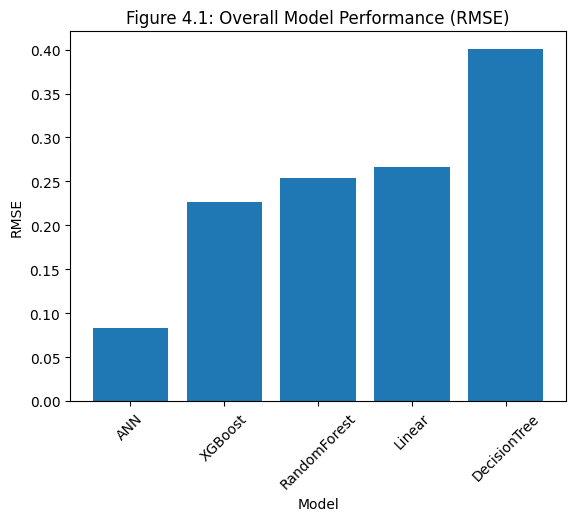

In [34]:
plt.figure()
plt.bar(table_41["Model"], table_41["RMSE"])
plt.title("Figure 4.1: Overall Model Performance (RMSE)")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.savefig("figure_4_1_model_comparison.png", bbox_inches="tight")
plt.show()

In [35]:
table_42 = results_df.sort_values(["State","RMSE"])

print("Table 4.2: Model Performance by State")
print(table_42.round(3))

Table 4.2: Model Performance by State
    State         Model    MAE   RMSE     R2
0   Ekiti           ANN  0.059  0.078  1.000
1   Ekiti       XGBoost  0.142  0.232  0.997
2   Ekiti  RandomForest  0.152  0.252  0.997
3   Ekiti        Linear  0.195  0.264  0.997
4   Ekiti  DecisionTree  0.268  0.413  0.992
5   Lagos           ANN  0.061  0.080  0.999
6   Lagos       XGBoost  0.126  0.191  0.997
7   Lagos        Linear  0.159  0.229  0.995
8   Lagos  RandomForest  0.136  0.246  0.994
9   Lagos  DecisionTree  0.231  0.361  0.988
10   Ogun           ANN  0.066  0.088  1.000
11   Ogun       XGBoost  0.145  0.235  0.997
12   Ogun  RandomForest  0.148  0.264  0.996
13   Ogun        Linear  0.180  0.265  0.996
14   Ogun  DecisionTree  0.260  0.406  0.990
15   Ondo           ANN  0.062  0.083  1.000
16   Ondo       XGBoost  0.139  0.226  0.997
17   Ondo  RandomForest  0.147  0.249  0.997
18   Ondo        Linear  0.181  0.250  0.997
19   Ondo  DecisionTree  0.263  0.408  0.991
20   Osun        

In [36]:
best_per_state = results_df.loc[
    results_df.groupby("State")["RMSE"].idxmin()
].reset_index(drop=True)

print("Best Model per State")
print(best_per_state.round(3))

Best Model per State
   State Model    MAE   RMSE     R2
0  Ekiti   ANN  0.059  0.078  1.000
1  Lagos   ANN  0.061  0.080  0.999
2   Ogun   ANN  0.066  0.088  1.000
3   Ondo   ANN  0.062  0.083  1.000
4   Osun   ANN  0.063  0.086  1.000
5    Oyo   ANN  0.064  0.086  1.000


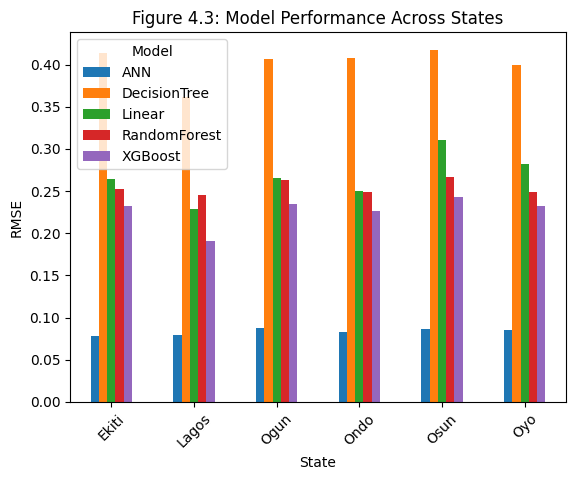

In [37]:
pivot_state = results_df.pivot(index="State", columns="Model", values="RMSE")

pivot_state.plot(kind="bar")
plt.title("Figure 4.3: Model Performance Across States")
plt.xlabel("State")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.savefig("figure_4_3_state_comparison.png", bbox_inches="tight")
plt.show()

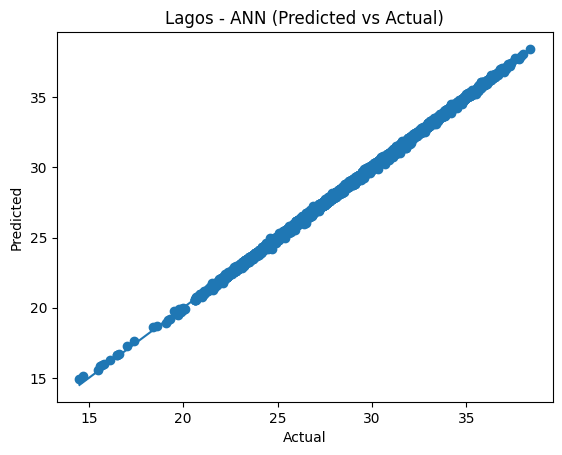

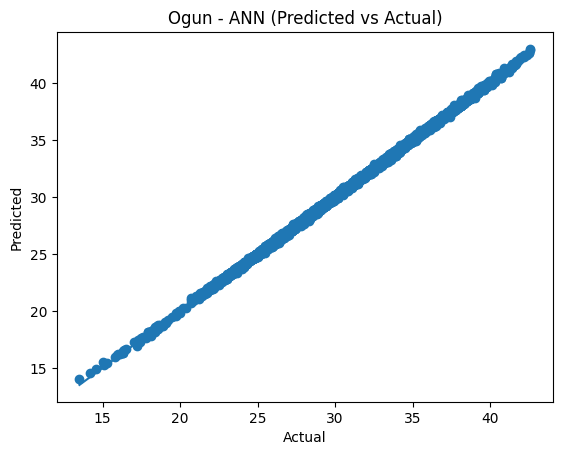

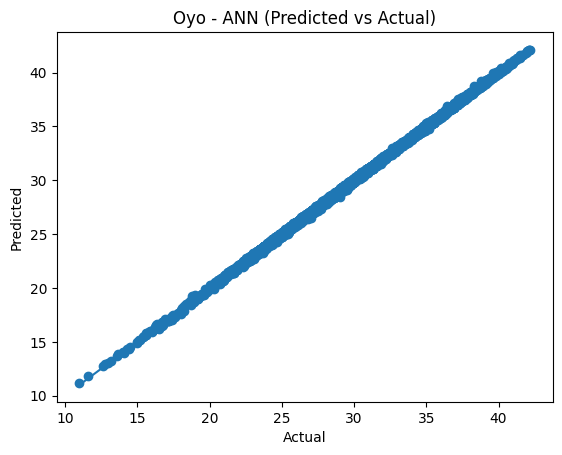

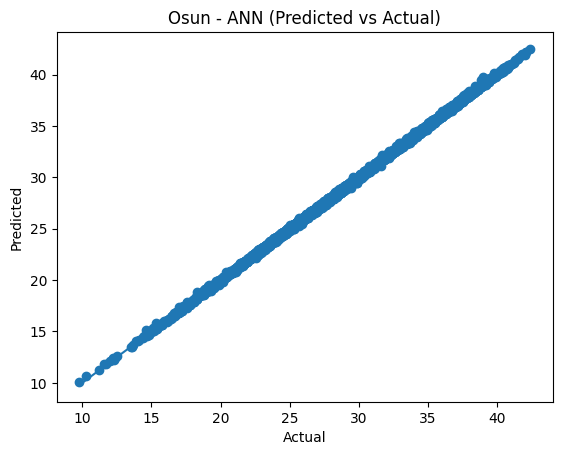

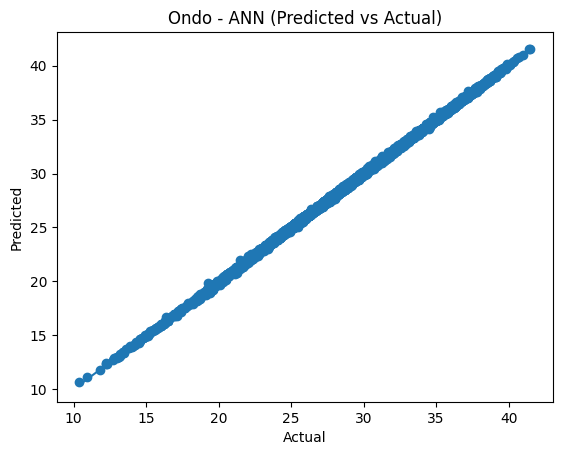

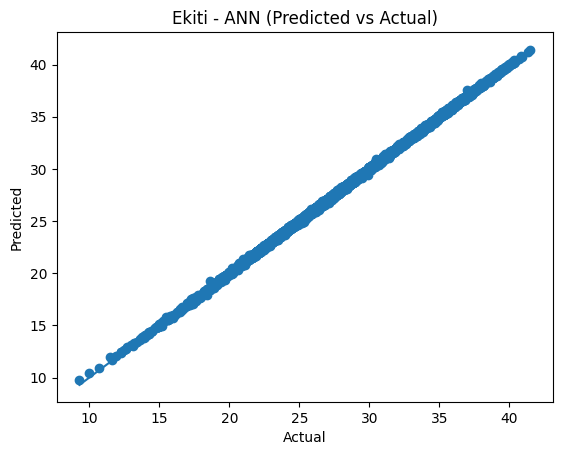

In [55]:
best_models = results_df.loc[
    results_df.groupby("State")["RMSE"].idxmin()
]

for state in states:

    best_model = best_models[best_models["State"] == state]["Model"].values[0]

    data = pred_df[
        (pred_df["State"] == state) &
        (pred_df["Model"] == best_model)
    ].iloc[0]

    y_test = data["y_test"]
    y_pred = data["y_pred"]

    plt.figure()
    plt.scatter(y_test, y_pred)
    plt.plot([min(y_test), max(y_test)],
             [min(y_test), max(y_test)])

    plt.title(f"{state} - {best_model} (Predicted vs Actual)")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.show()

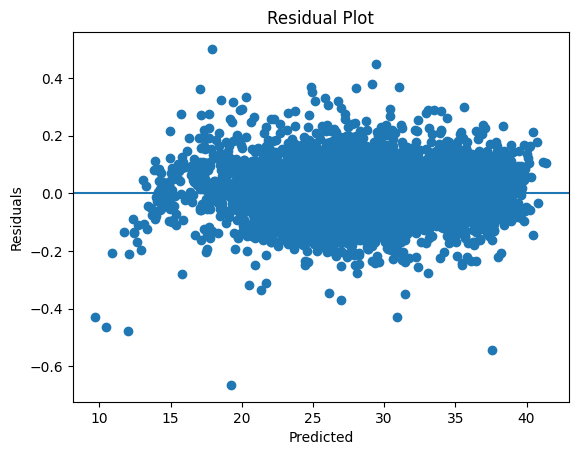

In [56]:
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.title("Residual Plot")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

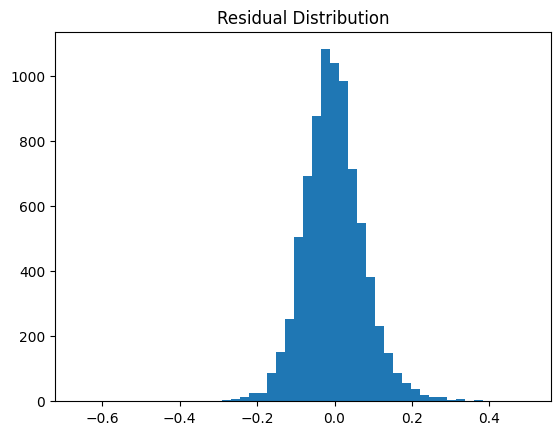

In [57]:
plt.figure()
plt.hist(residuals, bins=50)
plt.title("Residual Distribution")
plt.show()

In [58]:
state = "Lagos"

TARGET = f"utci_{state}"

features = [
    col for col in train.columns
    if col.startswith((f"ta_{state}", f"rh_{state}", f"ws_{state}", f"sr_{state}"))
    or col.startswith(("hour_","day_"))
]

X_train = train[features]
y_train = train[TARGET]

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=SEED)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


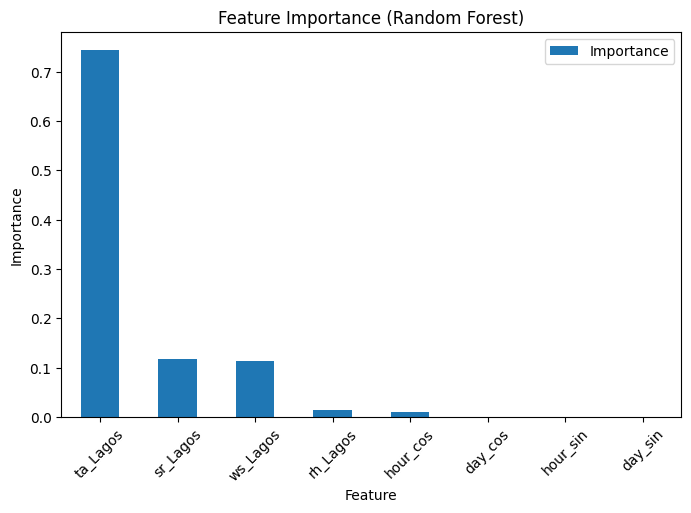

In [59]:
import pandas as pd

fi = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

fi.set_index("Feature").plot(kind="bar", figsize=(8,5))

plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.savefig("figure_feature_importance.png", bbox_inches="tight", dpi=300)
plt.show()

In [62]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np

states = ["Lagos","Ogun","Oyo","Osun","Ondo","Ekiti"]

all_importance = []

for state in states:

    TARGET = f"utci_{state}"

    features = [
        col for col in train.columns
        if col.startswith((f"ta_{state}", f"rh_{state}", f"ws_{state}", f"sr_{state}"))
        or col.startswith(("hour_","day_"))
    ]

    X_train = train[features]
    y_train = train[TARGET]

    rf = RandomForestRegressor(random_state=SEED)
    rf.fit(X_train, y_train)

    # Save importance
    for f, imp in zip(features, rf.feature_importances_):
        all_importance.append({
            "State": state,
            "Feature": f,
            "Importance": imp
        })

importance_df = pd.DataFrame(all_importance)

In [63]:
importance_df

,State,Feature,Importance
0,Lagos,rh_Lagos,0.014577
1,Lagos,sr_Lagos,0.118029
2,Lagos,ta_Lagos,0.743377
3,Lagos,ws_Lagos,0.112508
4,Lagos,hour_sin,0.000634
5,Lagos,hour_cos,0.009667
6,Lagos,day_sin,0.000504
7,Lagos,day_cos,0.000703
8,Ogun,rh_Ogun,0.026619
9,Ogun,sr_Ogun,0.112325


In [64]:
def get_var_type(feature):
    if "ta_" in feature:
        return "Temperature"
    elif "rh_" in feature:
        return "Humidity"
    elif "ws_" in feature:
        return "Wind Speed"
    elif "sr_" in feature:
        return "Radiation"
    else:
        return "Time"

importance_df["Variable"] = importance_df["Feature"].apply(get_var_type)

agg_importance = importance_df.groupby("Variable")["Importance"].mean().sort_values()

In [65]:
agg_importance

Variable
Time           0.001290
Wind Speed     0.048110
Humidity       0.050960
Radiation      0.068304
Temperature    0.827465
Name: Importance, dtype: float64

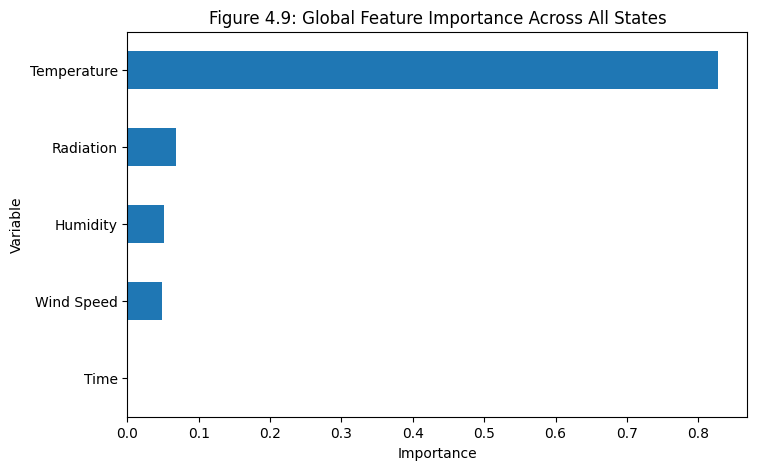

In [66]:
import matplotlib.pyplot as plt

agg_importance.plot(kind="barh", figsize=(8,5))

plt.title("Figure 4.9: Global Feature Importance Across All States")
plt.xlabel("Importance")
plt.ylabel("Variable")

plt.savefig("figure_4_9_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
wil

In [68]:
from scipy.stats import wilcoxon

wilcoxon_results = []

for state in states:

    TARGET = f"utci_{state}"

    features = [
        col for col in train.columns
        if col.startswith((f"ta_{state}", f"rh_{state}", f"ws_{state}", f"sr_{state}"))
        or col.startswith(("hour_","day_"))
    ]

    X_train = train[features]
    y_train = train[TARGET]

    X_test = test[features]
    y_test = test[TARGET]

    # Train models
    lr = LinearRegression().fit(X_train, y_train)
    rf = RandomForestRegressor(random_state=SEED).fit(X_train, y_train)

    y_pred_lr = lr.predict(X_test)
    y_pred_rf = rf.predict(X_test)

    # Compute errors
    errors_lr = abs(y_test - y_pred_lr)
    errors_rf = abs(y_test - y_pred_rf)

    # Wilcoxon test
    stat, p_value = wilcoxon(errors_rf, errors_lr)

    wilcoxon_results.append({
        "State": state,
        "p-value": p_value,
        "Significant": "Yes" if p_value < 0.05 else "No"
    })

wilcoxon_df = pd.DataFrame(wilcoxon_results)
print(wilcoxon_df)

   State        p-value Significant
0  Lagos   9.164627e-90         Yes
1   Ogun  1.054937e-110         Yes
2    Oyo  2.827581e-148         Yes
3   Osun  3.540082e-176         Yes
4   Ondo  1.369019e-120         Yes
5  Ekiti  2.945131e-148         Yes


In [72]:
wilcoxon_df

,State,p-value,Significant
0,Lagos,9.164627e-90,Yes
1,Ogun,1.054937e-110,Yes
2,Oyo,2.827581e-148,Yes
3,Osun,3.540082e-176,Yes
4,Ondo,1.369019e-120,Yes
5,Ekiti,2.945131e-148,Yes


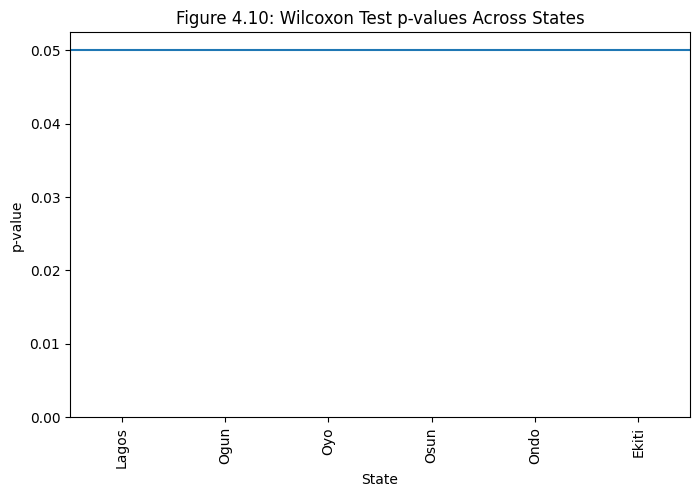

In [73]:
wilcoxon_df.set_index("State")["p-value"].plot(kind="bar", figsize=(8,5))

plt.axhline(0.05)  # significance line

plt.title("Figure 4.10: Wilcoxon Test p-values Across States")
plt.ylabel("p-value")
plt.xlabel("State")

plt.savefig("figure_4_10_wilcoxon.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
SPATIAL MAP

In [74]:
best_models = results_df.loc[
    results_df.groupby("State")["RMSE"].idxmin()
]

best_models = best_models.reset_index(drop=True)
print(best_models)

   State Model       MAE      RMSE        R2
0  Ekiti   ANN  0.059425  0.078436  0.999708
1  Lagos   ANN  0.060982  0.079574  0.999422
2   Ogun   ANN  0.066305  0.087931  0.999545
3   Ondo   ANN  0.062408  0.082769  0.999631
4   Osun   ANN  0.063200  0.086195  0.999658
5    Oyo   ANN  0.064445  0.085620  0.999607


In [75]:
coords = {
    "Lagos": (3.4, 6.5),
    "Ogun": (3.5, 7.0),
    "Oyo": (3.9, 7.5),
    "Osun": (4.6, 7.7),
    "Ondo": (5.2, 7.2),
    "Ekiti": (5.3, 7.8)
}

best_models["lon"] = best_models["State"].map(lambda x: coords[x][0])
best_models["lat"] = best_models["State"].map(lambda x: coords[x][1])

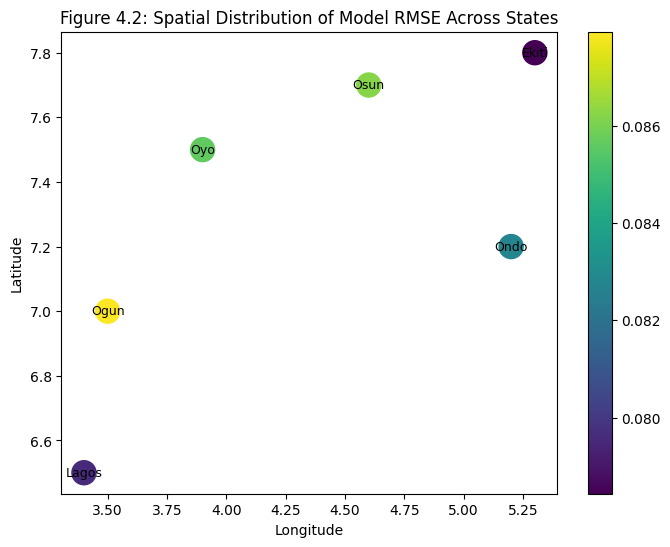

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sc = plt.scatter(
    best_models["lon"],
    best_models["lat"],
    c=best_models["RMSE"],   # color by error
    s=300                    # size of points
)

# Add labels
for i, row in best_models.iterrows():
    plt.text(row["lon"], row["lat"], row["State"], fontsize=9, ha='center', va='center')

plt.colorbar(sc)

plt.title("Figure 4.2: Spatial Distribution of Model RMSE Across States")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.savefig("figure_4_2_spatial_map.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
pip install geopandas

In [79]:
import geopandas as gpd

gdf = gpd.read_file("gadm41_NGA_1.shp")
gdf.head()

,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry
0,NGA.1_1,NGA,Nigeria,Abia,NA,NA,State,State,NA,NG.AB,NG-AB,"POLYGON ((7.46283 4.98177, 7.46261 4.96793, 7...."
1,NGA.2_1,NGA,Nigeria,Adamawa,NA,NA,State,State,NA,NG.AD,NG-AD,"POLYGON ((12.25072 8.17262, 12.24873 8.1702, 1..."
2,NGA.3_1,NGA,Nigeria,Akwa Ibom,NA,NA,State,State,NA,NG.AK,NG-AK,"MULTIPOLYGON (((8.31958 4.55764, 8.31958 4.557..."
3,NGA.4_1,NGA,Nigeria,Anambra,NA,NA,State,State,NA,NG.AN,NG-AN,"POLYGON ((6.93577 5.85795, 6.93626 5.84572, 6...."
4,NGA.5_1,NGA,Nigeria,Bauchi,NA,NA,State,State,NA,NG.BA,NG-BA,"POLYGON ((9.75266 9.60087, 9.73536 9.5673, 9.7..."


In [80]:
gdf.columns

Index(['GID_1', 'GID_0', 'COUNTRY', 'NAME_1', 'VARNAME_1', 'NL_NAME_1',
       'TYPE_1', 'ENGTYPE_1', 'CC_1', 'HASC_1', 'ISO_1', 'geometry'],
      dtype='object')

In [81]:
states = ["Lagos","Ogun","Oyo","Osun","Ondo","Ekiti"]

gdf_sw = gdf[gdf["NAME_1"].isin(states)]

In [83]:
gdf_sw

,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry
12,NGA.13_1,NGA,Nigeria,Ekiti,NA,NA,State,State,NA,NG.EK,NG-EK,"POLYGON ((5.59153 7.48823, 5.59101 7.48447, 5...."
24,NGA.25_1,NGA,Nigeria,Lagos,NA,NA,State,State,NA,NG.LA,NG-LA,"POLYGON ((3.39514 6.39653, 3.39542 6.39651, 3...."
27,NGA.28_1,NGA,Nigeria,Ogun,NA,NA,State,State,NA,NG.OG,NG-OG,"POLYGON ((4.3431 6.39377, 4.34478 6.39743, 4.3..."
28,NGA.29_1,NGA,Nigeria,Ondo,NA,NA,State,State,NA,NG.ON,NG-ON,"MULTIPOLYGON (((4.99764 5.86208, 4.99764 5.861..."
29,NGA.30_1,NGA,Nigeria,Osun,NA,NA,State,State,NA,NG.OS,NG-OS,"POLYGON ((4.11345 7.28703, 4.1156 7.30614, 4.1..."
30,NGA.31_1,NGA,Nigeria,Oyo,NA,NA,State,State,NA,NG.OY,NG-OY,"POLYGON ((3.94512 7.07097, 3.93238 7.06842, 3...."


In [84]:
best_models = results_df.loc[
    results_df.groupby("State")["RMSE"].idxmin()
]

best_models = best_models[["State","RMSE"]]

In [85]:
map_df = gdf_sw.merge(
    best_models,
    left_on="NAME_1",
    right_on="State"
)

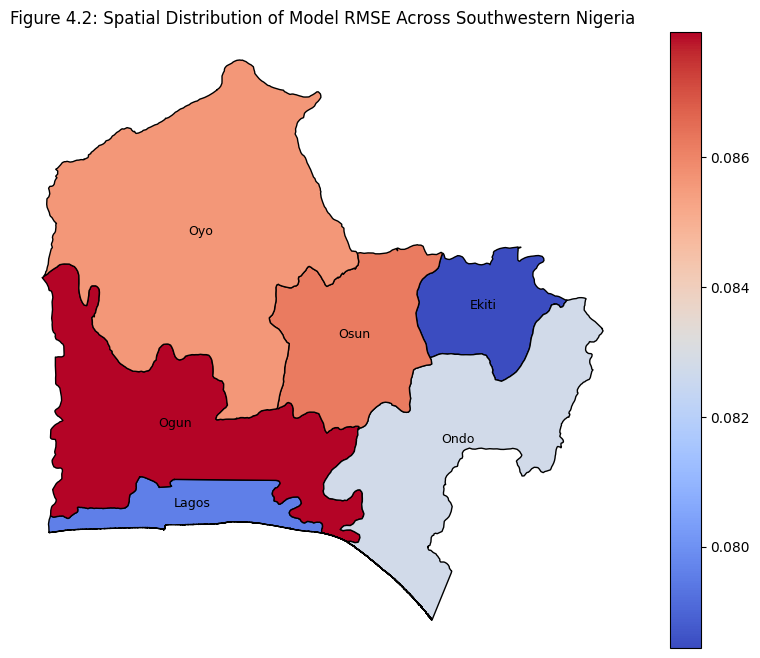

In [86]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,8))

map_df.plot(
    column="RMSE",
    cmap="coolwarm",
    legend=True,
    edgecolor="black",
    linewidth=1,
    ax=ax
)

# Add labels
for idx, row in map_df.iterrows():
    plt.annotate(
        text=row["NAME_1"],
        xy=(row.geometry.centroid.x, row.geometry.centroid.y),
        ha="center",
        fontsize=9,
        color="black"
    )

plt.title("Figure 4.2: Spatial Distribution of Model RMSE Across Southwestern Nigeria")
plt.axis("off")

plt.savefig("figure_4_2_spatial_map.png", dpi=300, bbox_inches="tight")
plt.show()

## Results Tables

In [61]:
results_df2 = pd.DataFrame(all_results)

results_df2 = results_df2.sort_values(["State","RMSE"]).reset_index(drop=True)

results_df2

,State,Model,MAE,RMSE,R2
0,Ekiti,ANN,0.059425,0.078436,0.999708
1,Ekiti,ANN_Tuned,0.083478,0.107276,0.999453
2,Ekiti,XGBoost_Tuned,0.108498,0.187734,0.998325
3,Ekiti,XGBoost,0.142167,0.231746,0.997447
4,Ekiti,RandomForest_Tuned,0.143407,0.241028,0.997238
5,Ekiti,RandomForest,0.151865,0.251858,0.996985
6,Ekiti,Linear,0.195259,0.263861,0.996690
7,Ekiti,DecisionTree,0.267770,0.413247,0.991882
8,Lagos,ANN_Tuned,0.037687,0.050531,0.999767
9,Lagos,ANN,0.060982,0.079574,0.999422


In [62]:
# Best Model Per State
best_models = results_df.loc[
    results_df.groupby("State")["RMSE"].idxmin()
]

best_models[["State","Model","RMSE","R2"]]

,State,Model,RMSE,R2
0,Ekiti,ANN,0.078436,0.999708
5,Lagos,ANN,0.079574,0.999422
10,Ogun,ANN,0.087931,0.999545
15,Ondo,ANN,0.082769,0.999631
20,Osun,ANN,0.086195,0.999658
25,Oyo,ANN,0.085620,0.999607


In [63]:
results_df2.to_csv("all_models_results.csv", index=False)

best_models.to_csv("best_model_per_state.csv", index=False)

In [ ]:
test

In [65]:
from scipy.stats import wilcoxon
import pandas as pd
import numpy as np


# Collect prediction errors

abs_errors = {}

for name, pred in pred_dict.items():
    abs_errors[name] = np.abs(y_test.values - pred)

# Pairwise Wilcoxon comparisons

comparisons = []

model_names = list(abs_errors.keys())

for i in range(len(model_names)):
    
    for j in range(i + 1, len(model_names)):
        
        m1 = model_names[i]
        m2 = model_names[j]

        stat, p = wilcoxon(
            abs_errors[m1],
            abs_errors[m2],
            alternative="two-sided"
        )

        comparisons.append({
            "Model_1": m1,
            "Model_2": m2,
            "Wilcoxon_stat": stat,
            "p_value": p
        })


wilcoxon_df = pd.DataFrame(comparisons)

wilcoxon_df = wilcoxon_df.sort_values("p_value")

wilcoxon_df.head(10)

,Model_1,Model_2,Wilcoxon_stat,p_value
3,Linear,ANN,3003028.0,0.000000e+00
6,DecisionTree,ANN,3030414.0,0.000000e+00
5,DecisionTree,XGBoost,8021485.5,0.000000e+00
4,DecisionTree,RandomForest,7198822.5,0.000000e+00
9,XGBoost,ANN,6389706.0,0.000000e+00
8,RandomForest,ANN,6971239.0,0.000000e+00
2,Linear,XGBoost,10554419.0,9.753903e-159
1,Linear,RandomForest,10744226.0,2.945131e-148
0,Linear,DecisionTree,13194846.0,2.105747e-45
7,RandomForest,XGBoost,16101409.0,8.743433e-01


## Modeling Plots

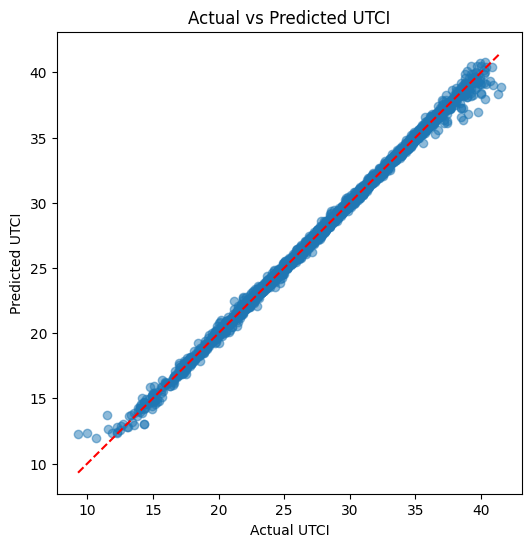

In [66]:
# Actual vs Predicted Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    pred_xgb_tuned,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual UTCI")
plt.ylabel("Predicted UTCI")

plt.title("Actual vs Predicted UTCI")

plt.show()

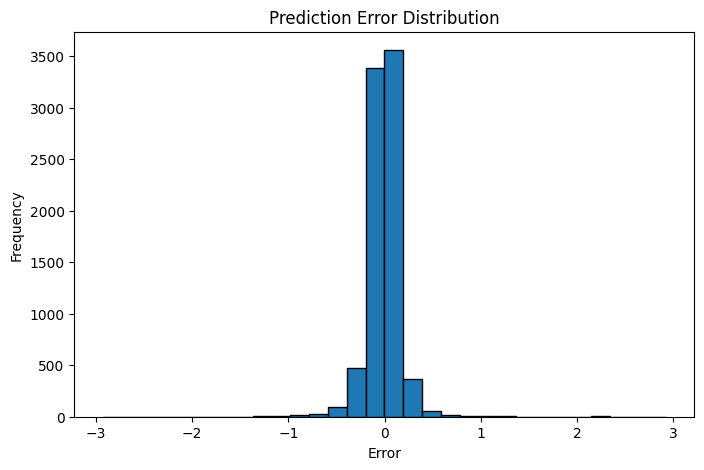

In [68]:
# Prediction Error Distribution
errors = y_test - pred_xgb_tuned

plt.figure(figsize=(8,5))

plt.hist(
    errors,
    bins=30,
    edgecolor="black"
)

plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")

plt.show()

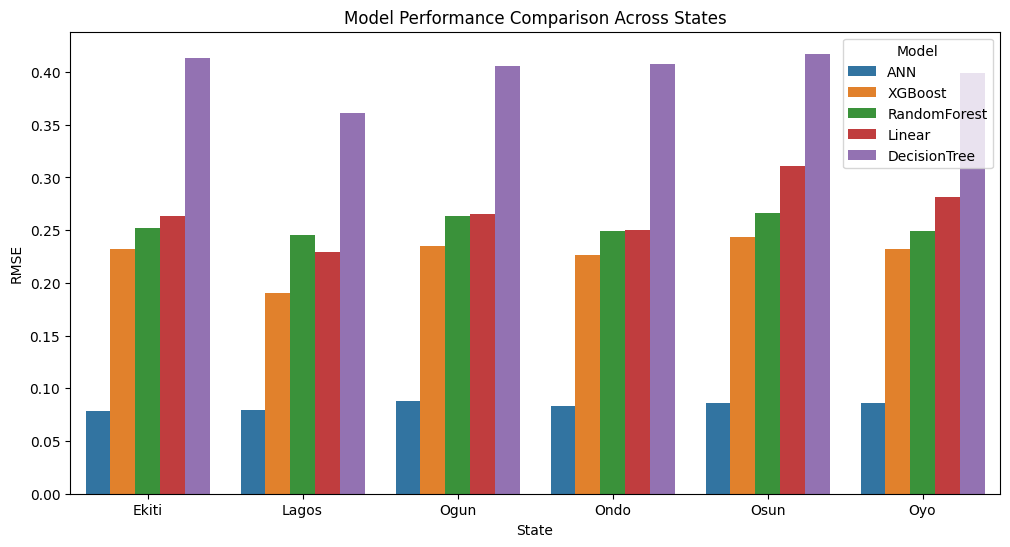

In [69]:
# Model Performance Comparison Plot
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x="State",
    y="RMSE",
    hue="Model"
)

plt.title("Model Performance Comparison Across States")
plt.ylabel("RMSE")

plt.show()

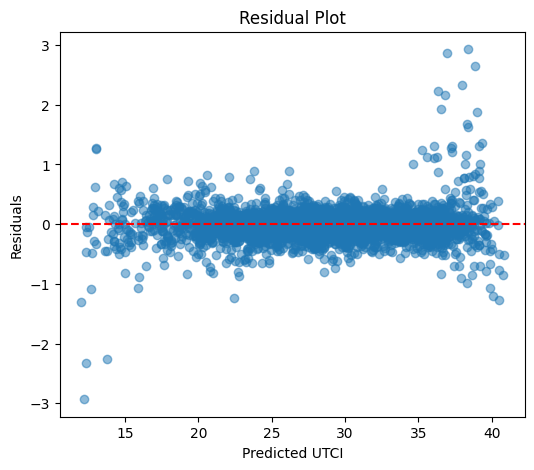

In [72]:
# Residual Plot
residuals = y_test - pred_xgb_tuned

plt.figure(figsize=(6,5))

plt.scatter(pred_xgb_tuned, residuals, alpha=0.5)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted UTCI")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

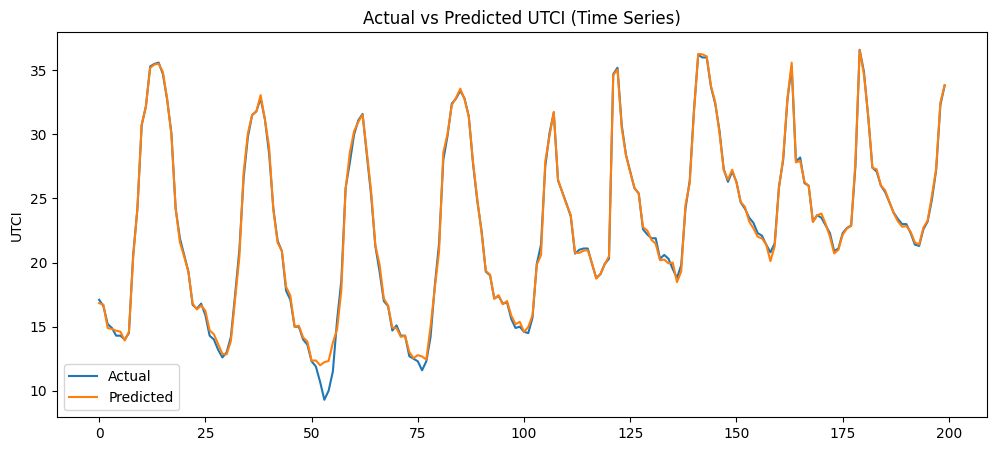

In [73]:
# Time-Series Prediction Plot
plt.figure(figsize=(12,5))

plt.plot(
    y_test.values[:200],
    label="Actual"
)

plt.plot(
    pred_xgb_tuned[:200],
    label="Predicted"
)

plt.legend()

plt.title("Actual vs Predicted UTCI (Time Series)")
plt.ylabel("UTCI")

plt.show()

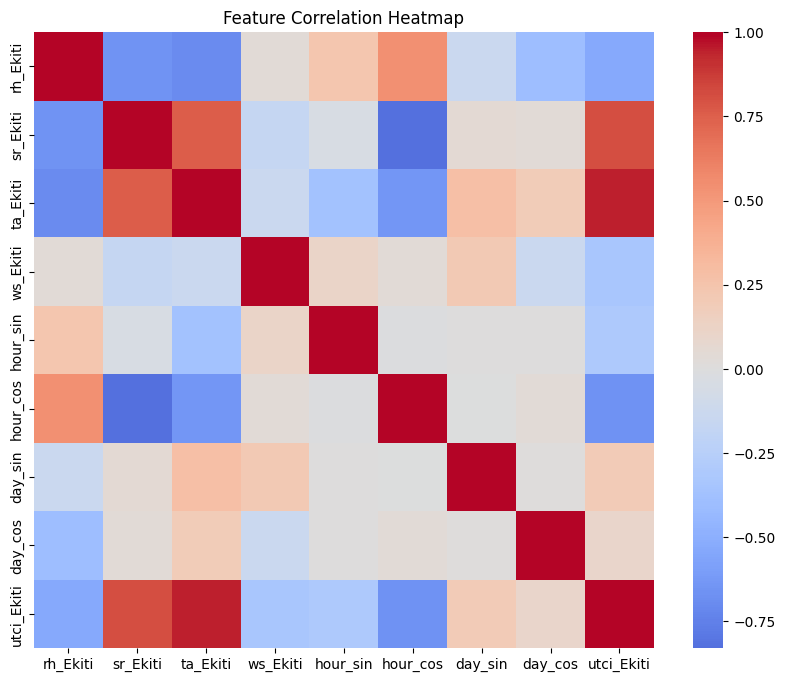

In [74]:
# Correlation Heatmap
import seaborn as sns

corr = train[features + [TARGET]].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")

plt.show()

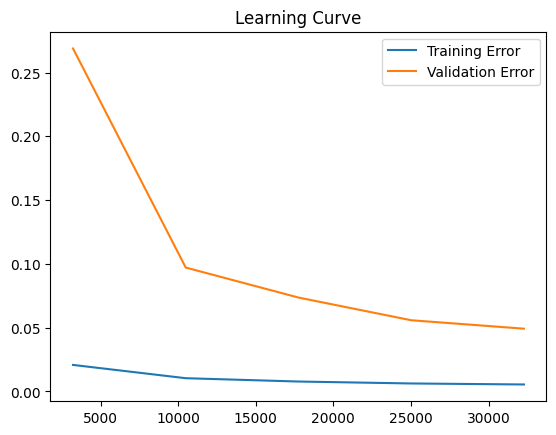

In [75]:
# Learning Curve Plot
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    RandomForestRegressor(random_state=SEED),
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_squared_error"
)

plt.plot(train_sizes, -train_scores.mean(axis=1), label="Training Error")
plt.plot(train_sizes, -val_scores.mean(axis=1), label="Validation Error")

plt.legend()

plt.title("Learning Curve")

plt.show()

C:\Users\User\anaconda3\envs\thermal_ml\lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


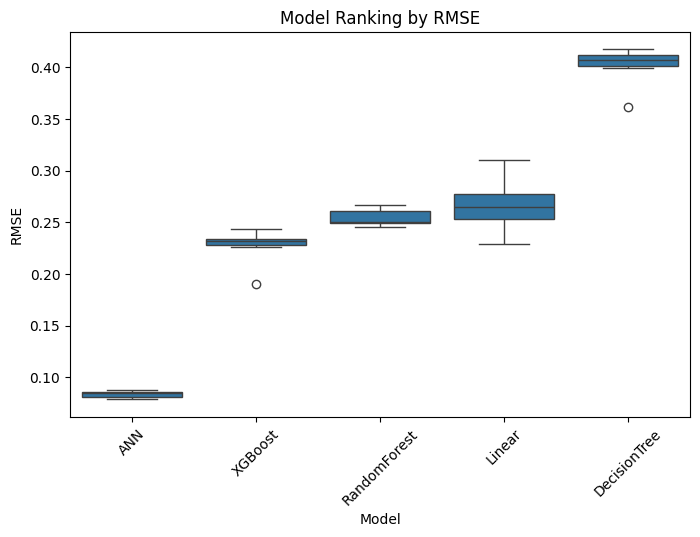

In [76]:
# Model Ranking Plot
plt.figure(figsize=(8,5))

sns.boxplot(
    data=results_df,
    x="Model",
    y="RMSE"
)

plt.xticks(rotation=45)

plt.title("Model Ranking by RMSE")

plt.show()

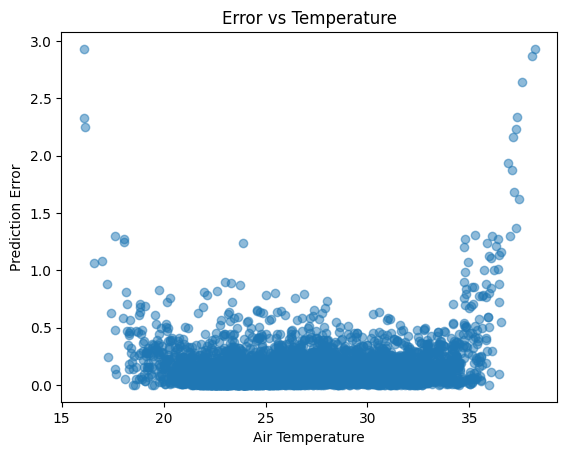

In [77]:
# Error vs Temperature Plot
plt.scatter(
    X_test["ta_Ekiti"],
    abs(y_test - pred_xgb_tuned),
    alpha=0.5
)

plt.xlabel("Air Temperature")
plt.ylabel("Prediction Error")

plt.title("Error vs Temperature")

plt.show()

C:\Users\User\anaconda3\envs\thermal_ml\lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


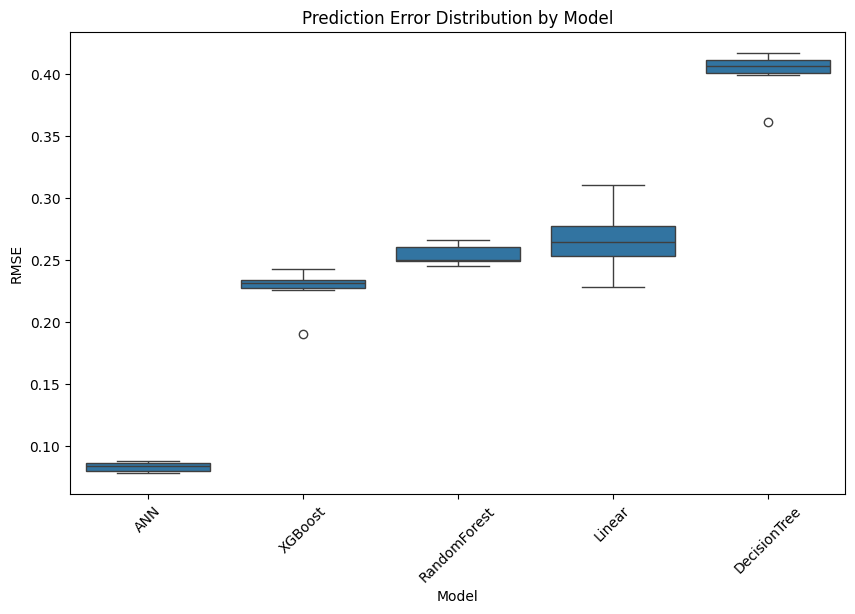

In [78]:
# Prediction Errors by Model
import seaborn as sns
import matplotlib.pyplot as plt

# create error column
results_df["Error"] = results_df["RMSE"]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=results_df,
    x="Model",
    y="Error"
)

plt.xticks(rotation=45)

plt.title("Prediction Error Distribution by Model")
plt.ylabel("RMSE")

plt.show()